# KATO Comprehensive Tutorial

Welcome to the complete guide to KATO (Knowledge Abstraction for Traceable Outcomes). This tutorial will teach you how to use KATO to learn patterns, make predictions, and build intelligent systems with complete transparency and explainability.

## What is KATO?

KATO is a deterministic AI system that:
- Learns temporal sequences from observations
- Makes predictions based on learned patterns
- Processes text, vectors, and emotions together
- Provides complete traceability for every decision
- Maintains isolated sessions for different contexts

## Tutorial Outline

1. **Starting KATO Server** - Getting KATO running
2. **Sessions and Configuration** - Creating isolated environments
3. **Basic Hello World** - First patterns and predictions
4. **Understanding Predictions** - Deep dive into prediction fields
5. **Prediction Metrics** - Confidence, frequency, and thresholds
6. **Working with Emotives** - Adding emotional context
7. **Vector Data** - Numeric representations
8. **Word2Vec Integration** - Semantic similarity
9. **Learning Modes** - Manual vs automatic learning
10. **Abstraction Chains** - Connecting multiple sessions
11. **Handwritten Digits** - Real-world vector classification
12. **Iris Flowers** - Classic ML benchmark
13. **Customer Churn** - Utility polarity prediction
14. **California Housing** - Utility value regression
15. **Auto MPG** - Recommendation engine with emotives

Let's begin!

## 1. Starting KATO Server

First, we need to get KATO running. KATO runs in Docker containers to ensure consistent behavior across different environments.

### Prerequisites
- Docker and Docker Compose installed
- KATO source code (available at the specified directory)

### Starting the Server

Open a terminal and navigate to the KATO directory, then run:

In [1]:
# Run this in your terminal (not in Jupyter)
# cd /path/to/kato
# docker-compose up -d

This starts several services:

- **KATO Service** (Port 8000): The main KATO processor that handles your requests
- **Storage Services**: Database systems that KATO uses to store patterns and manage sessions

### Docker Network Requirements for Jupyter

**Important**: If you're running this Jupyter notebook in a Docker container, it must be on the same Docker network as KATO to use the hostname `kato` instead of `localhost`.

KATO creates a Docker network called `kato_kato-network`. To run Jupyter on the same network:

```bash
# Start Jupyter Notebook on the same Docker network as KATO
docker run -it --rm \
  --network kato_kato-network \
  -p 8888:8888 \
  -v $(pwd):/home/jovyan/work \
  --name jupyter-kato \
  jupyter/scipy-notebook:latest
```

Or if you prefer to mount a specific directory:

```bash
# Mount the kato-notebooks directory specifically
docker run -it --rm \
  --network kato_kato-network \
  -p 8888:8888 \
  -v /path/to/kato-notebooks:/home/jovyan/work \
  --name jupyter-kato \
  jupyter/scipy-notebook:latest
```

### Connection Options

- **From host machine**: Use `http://localhost:8000`
- **From Docker container on same network**: Use `http://kato:8000`

### Verify KATO is Running

Let's check that KATO is healthy and ready to use:

In [2]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import json
import time

# KATO server URL
# Use "kato" if running Jupyter in Docker on the same network, "localhost" if running on host
KATO_URL = "http://kato:8000"  # For Docker containers on kato_kato-network
# KATO_URL = "http://localhost:8000"  # For host machine access


# Create a session with automatic retry for transient connection errors
# (e.g., when Uvicorn worker restarts after --limit-max-requests)
http = requests.Session()
retries = Retry(total=3, connect=3, backoff_factor=1.0, allowed_methods=["GET", "POST"])
http.mount("http://", HTTPAdapter(max_retries=retries))
http.mount("https://", HTTPAdapter(max_retries=retries))

def check_kato_health():
    """Check if KATO server is running and healthy"""
    try:
        response = http.get(f"{KATO_URL}/health", timeout=5)
        if response.status_code == 200:
            health_data = response.json()
            print("✅ KATO is healthy!")
            print(f"   Status: {health_data.get('status')}")
            print(f"   Service: {health_data.get('service_name', 'KATO')}")
            if 'uptime_seconds' in health_data:
                print(f"   Uptime: {health_data['uptime_seconds']} seconds")
            return True
        else:
            print(f"❌ KATO health check failed: {response.status_code}")
            return False
    except requests.exceptions.ConnectionError:
        print("❌ Cannot connect to KATO.")
        print("   Troubleshooting:")
        print("   1. Make sure Docker containers are running: docker-compose up -d")
        print("   2. If using 'kato' hostname, ensure Jupyter is on kato_kato-network")
        print("   3. Try changing KATO_URL to 'http://localhost:8000' if running on host")
        return False
    except Exception as e:
        print(f"❌ Error checking KATO health: {e}")
        return False

def verify_network_connectivity():
    """Verify Docker network connectivity"""
    try:
        # Try to resolve the hostname
        import socket
        socket.gethostbyname('kato')
        print("✅ Network connectivity: Can resolve 'kato' hostname")
        return True
    except socket.gaierror:
        print("❌ Network connectivity: Cannot resolve 'kato' hostname")
        print("   This means Jupyter is not on the same Docker network as KATO")
        print("   Either:")
        print("   1. Start Jupyter with --network kato_kato-network")
        print("   2. Change KATO_URL to use 'localhost' instead of 'kato'")
        return False

# Check network connectivity first
print("🔍 Checking network connectivity...")
verify_network_connectivity()

print("\n🏥 Checking KATO health...")
# Check KATO health
check_kato_health()

🔍 Checking network connectivity...
✅ Network connectivity: Can resolve 'kato' hostname

🏥 Checking KATO health...
✅ KATO is healthy!
   Status: healthy
   Service: kato
   Uptime: 1225.4091773033142 seconds


True

If you see "✅ KATO is healthy!", you're ready to proceed! 

**Troubleshooting Connection Issues:**

1. **Cannot resolve 'kato' hostname**: Your Jupyter container is not on the same Docker network
   - Solution: Start Jupyter with `--network kato_kato-network` option
   - Alternative: Change `KATO_URL` to `"http://localhost:8000"`

2. **Connection refused**: KATO containers are not running
   - Solution: Run `docker-compose up -d` in the KATO directory

3. **Mixed setup**: If running Jupyter on host but KATO in Docker
   - Use `KATO_URL = "http://localhost:8000"`

## 2. Creating Sessions and Configuration

KATO uses **sessions** to provide isolated environments for different contexts or users. Each session has its own:
- Short-term memory (working memory)
- Emotional state
- Configuration settings

### Multi-User Architecture

KATO supports multiple users simultaneously through session isolation:

- **Node ID**: Each session is associated with a node ID for complete isolation
- **Session ID**: Unique identifier for each session within a node's context
- **Time-to-Live (TTL)**: Sessions automatically expire after a configurable timeout
- **Metadata**: Custom configuration stored with each session

### Session Configuration Options

When creating a session, you can configure:

- **`max_pattern_length`**: Controls auto-learning behavior
  - `0`: Manual learning only (you control when to learn)
  - `> 0`: Auto-learn when short-term memory reaches this size

- **`recall_threshold`**: Prediction sensitivity (0.0 to 1.0)
  - `0.0`: Return all possible predictions
  - `1.0`: Only return perfect matches
  - `0.1`: Good default for flexible matching

- **`node_id`**: Node identifier for session isolation
  - If not provided, a random ID is generated
  - Different nodes cannot access each other's sessions

Let's create our first session:

In [3]:
def create_session(name, max_pattern_length=0, recall_threshold=0.1, node_id=None):
    """Create a new KATO session with specified configuration"""
    # Generate a default node_id if none provided
    if node_id is None:
        import uuid
        node_id = f"tutorial_node_{uuid.uuid4().hex[:8]}"
    
    session_config = {
        "node_id": node_id,  # Required for processor isolation
        "config": {
            "max_pattern_length": max_pattern_length,
            "recall_threshold": recall_threshold
        },
        "ttl_seconds": 3600,  # 1 hour session timeout
        "metadata": {
            "name": name
        }
    }
    
    response = http.post(f"{KATO_URL}/sessions", json=session_config)
    
    if response.status_code == 200:
        session_data = response.json()
        session_id = session_data['session_id']
        node_id = session_data['node_id']
        print(f"✅ Created session: {name}")
        print(f"   Session ID: {session_id}")
        print(f"   Node ID: {node_id}")
        print(f"   Max pattern length: {max_pattern_length} {'(manual learning)' if max_pattern_length == 0 else '(auto-learn)'}")
        print(f"   Recall threshold: {recall_threshold}")
        return session_id
    else:
        print(f"❌ Failed to create session: {response.status_code}")
        print(response.text)
        return None

def get_session_info(session_id):
    """Get information about a session"""
    response = http.get(f"{KATO_URL}/sessions/{session_id}")
    if response.status_code == 200:
        return response.json()
    else:
        print(f"❌ Failed to get session info: {response.status_code}")
        return None

# Create our tutorial session
tutorial_session = create_session(
    node_id="my-agent-1",
    name="Tutorial Session",
    max_pattern_length=0,      # Manual learning
    recall_threshold=0.1       # Flexible matching
)

print(f"\n📝 We'll use session {tutorial_session} for the rest of this tutorial.")

✅ Created session: Tutorial Session
   Session ID: session-a03547971bad4308a2298e26a22fec68-1773859562917
   Node ID: my-agent-1
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1

📝 We'll use session session-a03547971bad4308a2298e26a22fec68-1773859562917 for the rest of this tutorial.


# API

These are some of the available API commands.

You can also review them using KATO's Swagger documentation:
http://localhost:8000/docs

In [4]:
def observe(session_id, strings=None, vectors=None, emotives=None):
    """Send an observation to KATO"""
    observation = {
        "strings": strings or [],
        "vectors": vectors or [],
        "emotives": emotives or {}
    }
    
    response = http.post(f"{KATO_URL}/sessions/{session_id}/observe", json=observation)
    
    if response.status_code == 200:
        result = response.json()
        print(f"📥 Observed: {strings}")
        return result
    else:
        print(f"❌ Observation failed: {response.status_code}")
        print(response.text)
        return None

def clear_all_memory(session_id):
    """Clear ALL memory (STM and learned patterns) for a session.
    Use POST /sessions/{id}/clear-all for a complete fresh start before training."""
    response = http.post(f"{KATO_URL}/sessions/{session_id}/clear-all", json={})
    if response.status_code == 200:
        print("🧹 Cleared all memory")
        return True
    else:
        print(f"❌ Failed to clear all memory: {response.status_code}")
        return False

def clear_stm(session_id):
    """Clear short-term memory"""
    response = http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})
    if response.status_code == 200:
        print("🧹 Cleared short-term memory")
        return True
    else:
        print(f"❌ Failed to clear STM: {response.status_code}")
        return False

def get_stm(session_id):
    """Get the current short-term memory"""
    response = http.get(f"{KATO_URL}/sessions/{session_id}/stm")
    if response.status_code == 200:
        return response.json()['stm']
    else:
        print(f"❌ Failed to get STM: {response.status_code}")
        return None

def get_predictions(session_id):
    """Get predictions from KATO"""
    response = http.get(f"{KATO_URL}/sessions/{session_id}/predictions")
    
    if response.status_code == 200:
        return response.json()
    else:
        print(f"❌ Failed to get predictions: {response.status_code}")
        return None

def learn(session_id):
    """Trigger learning from short-term memory"""
    response = http.post(f"{KATO_URL}/sessions/{session_id}/learn", json={})
    
    if response.status_code == 200:
        result = response.json()
        pattern_name = result.get('pattern_name')
        if pattern_name:
            print(f"🎓 Learned pattern: {pattern_name}")
            return pattern_name
        else:
            print("📚 No pattern learned (need more observations)")
            return None
    else:
        print(f"❌ Learning failed: {response.status_code}")
        print(response.text)
        return None

def get_pattern(pattern_id, node_id=None):
    """Retrieve a learned pattern by name"""
    params = {}
    if node_id:
        params['node_id'] = node_id
    response = http.get(f"{KATO_URL}/pattern/{pattern_id}", params=params)
    
    if response.status_code == 200:
        return response.json()
    else:
        print(f"❌ Failed to get pattern: {response.status_code}")
        return None

def update_session_config(session_id, config):
    """Update session configuration parameters.
    Example: update_session_config(session_id, {"recall_threshold": 0.3})
    """
    response = http.post(
        f"{KATO_URL}/sessions/{session_id}/config",
        json={"config": config}
    )
    if response.status_code == 200:
        print(f"✅ Updated config: {config}")
        return True
    else:
        print(f"❌ Failed to update config: {response.status_code}")
        return False

def train_sequences(session_id, sequences, verbose=True):
    """Train KATO on a list of sequences.
    Each sequence is a list of events: [{strings:[], vectors:[], emotives:{}}, ...]
    Pattern: clear_stm -> observe each event -> learn
    """
    trained = 0
    for seq in sequences:
        http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})
        for event in seq:
            http.post(f"{KATO_URL}/sessions/{session_id}/observe", json=event)
        http.post(f"{KATO_URL}/sessions/{session_id}/learn", json={})
        trained += 1
        if verbose and trained % 200 == 0:
            print(f"  Trained {trained}/{len(sequences)} samples...")
    if verbose:
        print(f"✅ Training complete: {trained} patterns learned")
    return trained

def test_classification(session_id, test_sequences, label_extractor=None):
    """Test KATO classification on sequences where the last event contains the label.
    Returns (predictions_list, actuals_list) for accuracy computation.

    label_extractor: function to extract label from the answer event.
        Default: event['strings'][0] (first string in the answer event)
    """
    if label_extractor is None:
        label_extractor = lambda event: event['strings'][0]

    predictions_list = []
    actuals_list = []

    for seq in test_sequences:
        http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})

        # Observe all events except the last (which contains the answer)
        for event in seq[:-1]:
            http.post(f"{KATO_URL}/sessions/{session_id}/observe", json=event)

        # Get predictions
        response = http.get(f"{KATO_URL}/sessions/{session_id}/predictions")
        preds = response.json() if response.status_code == 200 else {"predictions": []}

        predictions_list.append(preds)
        actuals_list.append(label_extractor(seq[-1]))

    return predictions_list, actuals_list

print("✨ API functions ready!")

✨ API functions ready!


### Understanding Nodes for Modular Learning

**Important Architecture Note**: KATO ties learned patterns to the `node_id`, not the session ID. This means:

- **Sessions with the same node_id**: Share learned patterns (only STM is isolated)
- **Sessions with different node_ids**: Have completely isolated patterns

**Nodes Concept**: To achieve isolated learning contexts, we use different `node_id` values as modular processing units. Each node can learn and maintain its own specialized patterns. Multiple nodes can be connected together to create data flow pipelines, where the output of one node becomes the input of another node.

**Example Use Cases for Connected Nodes**:
- `node_john_weather` → `node_john_forecast` (weather data → prediction)
- `node_john_stocks` → `node_john_portfolio` (stock data → investment advice)  
- `node_john_text` → `node_john_sentiment` → `node_john_response` (text → emotion → reply)

Each node maintains completely isolated learned patterns while providing persistence when you reconnect later.

**Node Chaining**: Nodes can be connected in pipelines:
1. **Data Processing Chain**: Raw data → Feature extraction → Pattern recognition → Decision
2. **Multi-Stage Learning**: Input validation → Core processing → Output formatting
3. **Hierarchical Analysis**: Low-level patterns → Mid-level abstractions → High-level insights

This modular approach allows you to build complex AI systems by connecting specialized nodes, each responsible for a specific aspect of the overall processing pipeline.

In [5]:
def create_node(user_name, node_purpose, max_pattern_length=0, recall_threshold=0.1):
    """Create a node (node_id) for isolated learning contexts"""
    node_id = f"node_{user_name}_{node_purpose}"
    session_name = f"{user_name.title()}'s {node_purpose.title()} Node"
    
    session_id = create_session(
        name=session_name,
        node_id=node_id,
        max_pattern_length=max_pattern_length,
        recall_threshold=recall_threshold
    )
    
    return session_id, node_id

def reconnect_to_node(user_name, node_purpose, max_pattern_length=0, recall_threshold=0.1):
    """Reconnect to an existing node to access its learned patterns"""
    node_id = f"node_{user_name}_{node_purpose}"
    session_name = f"{user_name.title()}'s {node_purpose.title()} Node (Reconnected)"
    
    session_id = create_session(
        name=session_name,
        node_id=node_id,  # Same node_id = access to same patterns
        max_pattern_length=max_pattern_length,
        recall_threshold=recall_threshold
    )
    
    return session_id, node_id

# Create multiple nodes for the same user (John)
weather_session, weather_node = create_node("john", "weather")
stocks_session, stocks_node = create_node("john", "stocks", max_pattern_length=5, recall_threshold=0.3)
assistant_session, assistant_node = create_node("john", "assistant")

print("\n🔗 Created Nodes for User 'John':")
print(f"   Weather Node:   {weather_node}")
print(f"   Stocks Node:    {stocks_node}")
print(f"   Assistant Node: {assistant_node}")
print("\n   Each node has completely isolated learned patterns!")
print("   John can learn weather patterns without affecting stock patterns.")
print("   Nodes can be connected: Weather → Forecast → Response pipeline")

✅ Created session: John's Weather Node
   Session ID: session-3325389500864aa3a0173ff7d7acc147-1773859563110
   Node ID: node_john_weather
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
✅ Created session: John's Stocks Node
   Session ID: session-43e7563acf894724aad62d72afc5fad2-1773859563115
   Node ID: node_john_stocks
   Max pattern length: 5 (auto-learn)
   Recall threshold: 0.3
✅ Created session: John's Assistant Node
   Session ID: session-e67fd15b35514954990ad8d4c5702387-1773859563119
   Node ID: node_john_assistant
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1

🔗 Created Nodes for User 'John':
   Weather Node:   node_john_weather
   Stocks Node:    node_john_stocks
   Assistant Node: node_john_assistant

   Each node has completely isolated learned patterns!
   John can learn weather patterns without affecting stock patterns.
   Nodes can be connected: Weather → Forecast → Response pipeline


In [6]:
# Demonstration 1: Teaching different patterns to each node
print("🧠 Teaching Different Patterns to Each Node")
print("=" * 50)

# Teach weather patterns to weather node
print("\n🌦️  Teaching Weather Patterns to Weather Node:")
clear_stm(weather_session)
observe(weather_session, strings=["sunny"])
observe(weather_session, strings=["day"])
observe(weather_session, strings=["temperature"])
observe(weather_session, strings=["rising"])

weather_pattern = learn(weather_session)
print(f"   ✅ Weather node learned: {weather_pattern}")

# Teach stock patterns to stocks node  
print("\n📈 Teaching Stock Patterns to Stocks Node:")
clear_stm(stocks_session)
observe(stocks_session, strings=["apple"])
observe(stocks_session, strings=["stock"])
observe(stocks_session, strings=["price"])
observe(stocks_session, strings=["climbing"])

stocks_pattern = learn(stocks_session)
print(f"   ✅ Stocks node learned: {stocks_pattern}")

# Teach assistant patterns to assistant node
print("\n🤖 Teaching Assistant Patterns to Assistant Node:")
clear_stm(assistant_session)
observe(assistant_session, strings=["schedule"])
observe(assistant_session, strings=["meeting"])
observe(assistant_session, strings=["calendar"])
observe(assistant_session, strings=["update"])

assistant_pattern = learn(assistant_session)
print(f"   ✅ Assistant node learned: {assistant_pattern}")

print("\n✨ All nodes have learned different, isolated patterns!")
print("💡 Pipeline Example: Weather Node → Forecast Node → Alert Node")

🧠 Teaching Different Patterns to Each Node

🌦️  Teaching Weather Patterns to Weather Node:
🧹 Cleared short-term memory
📥 Observed: ['sunny']
📥 Observed: ['day']
📥 Observed: ['temperature']
📥 Observed: ['rising']
🎓 Learned pattern: PTRN|9c2dbe8692927489be2a7d7f39ee33b7eafa9fcd
   ✅ Weather node learned: PTRN|9c2dbe8692927489be2a7d7f39ee33b7eafa9fcd

📈 Teaching Stock Patterns to Stocks Node:
🧹 Cleared short-term memory
📥 Observed: ['apple']
📥 Observed: ['stock']
📥 Observed: ['price']
📥 Observed: ['climbing']
🎓 Learned pattern: PTRN|c8273664b7520d599ab6e762715ff9f11e6465e4
   ✅ Stocks node learned: PTRN|c8273664b7520d599ab6e762715ff9f11e6465e4

🤖 Teaching Assistant Patterns to Assistant Node:
🧹 Cleared short-term memory
📥 Observed: ['schedule']
📥 Observed: ['meeting']
📥 Observed: ['calendar']
📥 Observed: ['update']
🎓 Learned pattern: PTRN|8d786a00122d904d489ea9b0cf60d2f8eb28264c
   ✅ Assistant node learned: PTRN|8d786a00122d904d489ea9b0cf60d2f8eb28264c

✨ All nodes have learned different,

### Working with Nodes - Demonstration

Now let's demonstrate how nodes work by teaching different patterns to each node and showing that they remain completely isolated.

**Node Isolation Test**: We'll:
1. Teach weather patterns to the weather node
2. Teach stock patterns to the stocks node  
3. Show that each node only knows its own patterns
4. Demonstrate persistence by reconnecting to nodes later
5. Show how nodes could be connected in processing pipelines

In [7]:
# Demonstration 2: Test node isolation
print("\n🔍 Testing Node Isolation")
print("=" * 40)

def test_node_predictions(session_id, node_name, test_context, expected_domain):
    """Test what each node predicts for different contexts"""
    print(f"\n🧪 Testing {node_name} with context: {test_context}")
    
    clear_stm(session_id)
    for word in test_context:
        observe(session_id, strings=[word])
    
    predictions = get_predictions(session_id)
    if predictions and 'predictions' in predictions and predictions['predictions']:
        for pred in predictions['predictions']:
            print(f"   🔮 Prediction: {pred.get('future', [])}")
            print(f"   📊 Confidence: {pred.get('confidence', 0):.3f}")
            print(f"   ✅ Pattern Domain: {expected_domain}")
    else:
        print(f"   ❌ No predictions (context doesn't match {expected_domain} patterns)")

# Test 1: Weather context on all nodes
print("🌦️  Test 1: Weather context ['sunny', 'day'] on all nodes")
test_node_predictions(weather_session, "Weather Node", ["sunny", "day"], "Weather")
test_node_predictions(stocks_session, "Stocks Node", ["sunny", "day"], "Weather")  
test_node_predictions(assistant_session, "Assistant Node", ["sunny", "day"], "Weather")

# Test 2: Stock context on all nodes  
print("\n📈 Test 2: Stock context ['apple', 'stock'] on all nodes")
test_node_predictions(weather_session, "Weather Node", ["apple", "stock"], "Stocks")
test_node_predictions(stocks_session, "Stocks Node", ["apple", "stock"], "Stocks")
test_node_predictions(assistant_session, "Assistant Node", ["apple", "stock"], "Stocks")

# Test 3: Assistant context on all nodes
print("\n🤖 Test 3: Assistant context ['schedule', 'meeting'] on all nodes")
test_node_predictions(weather_session, "Weather Node", ["schedule", "meeting"], "Assistant")
test_node_predictions(stocks_session, "Stocks Node", ["schedule", "meeting"], "Assistant")
test_node_predictions(assistant_session, "Assistant Node", ["schedule", "meeting"], "Assistant")


🔍 Testing Node Isolation
🌦️  Test 1: Weather context ['sunny', 'day'] on all nodes

🧪 Testing Weather Node with context: ['sunny', 'day']
🧹 Cleared short-term memory
📥 Observed: ['sunny']
📥 Observed: ['day']
   🔮 Prediction: [['temperature'], ['rising']]
   📊 Confidence: 1.000
   ✅ Pattern Domain: Weather

🧪 Testing Stocks Node with context: ['sunny', 'day']
🧹 Cleared short-term memory
📥 Observed: ['sunny']
📥 Observed: ['day']
   ❌ No predictions (context doesn't match Weather patterns)

🧪 Testing Assistant Node with context: ['sunny', 'day']
🧹 Cleared short-term memory
📥 Observed: ['sunny']
📥 Observed: ['day']
   ❌ No predictions (context doesn't match Weather patterns)

📈 Test 2: Stock context ['apple', 'stock'] on all nodes

🧪 Testing Weather Node with context: ['apple', 'stock']
🧹 Cleared short-term memory
📥 Observed: ['apple']
📥 Observed: ['stock']
   ❌ No predictions (context doesn't match Stocks patterns)

🧪 Testing Stocks Node with context: ['apple', 'stock']
🧹 Cleared short-t

In [8]:
# Demonstration 3: Node persistence - reconnecting to nodes
print("\n🔄 Testing Node Persistence")
print("=" * 35)

print("🔌 Reconnecting to John's nodes to access previously learned patterns...")

# Reconnect to each node (simulating coming back later)
weather_session_2, weather_node_2 = reconnect_to_node("john", "weather")
stocks_session_2, stocks_node_2 = reconnect_to_node("john", "stocks")  
assistant_session_2, assistant_node_2 = reconnect_to_node("john", "assistant")

print(f"\n✅ Reconnected to nodes:")
print(f"   Weather:   {weather_node_2}")
print(f"   Stocks:    {stocks_node_2}")
print(f"   Assistant: {assistant_node_2}")

# Test that patterns persist across reconnections
print("\n🧪 Testing that learned patterns persist after reconnection:")

print("\n🌦️  Weather Node (reconnected) - Test with 'sunny', 'day':")
clear_stm(weather_session_2)
observe(weather_session_2, strings=["sunny"])
observe(weather_session_2, strings=["day"])
predictions = get_predictions(weather_session_2)
if predictions and 'predictions' in predictions and predictions['predictions']:
    for pred in predictions['predictions']:
        print(f"   🔮 Still remembers: {pred.get('future', [])}")
        print(f"   📊 Confidence: {pred.get('confidence', 0):.3f}")
else:
    print("   ❌ Pattern not found - something went wrong!")

print("\n📈 Stocks Node (reconnected) - Test with 'apple', 'stock':")
clear_stm(stocks_session_2)
observe(stocks_session_2, strings=["apple"])
observe(stocks_session_2, strings=["stock"])
predictions = get_predictions(stocks_session_2)
if predictions and 'predictions' in predictions and predictions['predictions']:
    for pred in predictions['predictions']:
        print(f"   🔮 Still remembers: {pred.get('future', [])}")
        print(f"   📊 Confidence: {pred.get('confidence', 0):.3f}")
else:
    print("   ❌ Pattern not found - something went wrong!")

print("\n🎉 Node Summary:")
print("   ✅ Each node learned and retained its own specialized patterns")
print("   ✅ Patterns remain isolated between nodes")
print("   ✅ Patterns persist when reconnecting to nodes")
print("   ✅ User 'John' can maintain separate learning contexts!")

print("\n💡 Practical Applications:")
print("   📊 Data Pipeline: node_sarah_input → node_sarah_process → node_sarah_output")
print("   🏠 Smart Home: node_family_sensors → node_family_analysis → node_family_control")
print("   📱 Multi-Stage: node_mike_text → node_mike_nlp → node_mike_response")
print("   🎮 AI Gaming: node_alex_perception → node_alex_strategy → node_alex_action")

print("\n🔗 Node Chaining Examples:")
print("   🌡️  Weather: Input Node → Analysis Node → Forecast Node → Alert Node")
print("   💰 Trading: Market Node → Signal Node → Strategy Node → Execution Node")
print("   🗣️  Chat: Parse Node → Context Node → Generate Node → Format Node")


🔄 Testing Node Persistence
🔌 Reconnecting to John's nodes to access previously learned patterns...
✅ Created session: John's Weather Node (Reconnected)
   Session ID: session-6967e67ef76d477b8e3826cd566f7a40-1773859564154
   Node ID: node_john_weather
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
✅ Created session: John's Stocks Node (Reconnected)
   Session ID: session-c4c59872e87a4d2dbd0c2891a61a0ae3-1773859564161
   Node ID: node_john_stocks
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
✅ Created session: John's Assistant Node (Reconnected)
   Session ID: session-b251261651db40e6a311bddb70499a89-1773859564166
   Node ID: node_john_assistant
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1

✅ Reconnected to nodes:
   Weather:   node_john_weather
   Stocks:    node_john_stocks
   Assistant: node_john_assistant

🧪 Testing that learned patterns persist after reconnection:

🌦️  Weather Node (reconnected) - Test with 'sunny',

## 3. Basic Hello World Example

Now let's start working with KATO! We'll begin with a simple "hello world" example to understand how KATO learns patterns and makes predictions.

### Making Observations

KATO learns from **observations**. Each observation can contain:
- **strings**: Text data (list of strings)
- **vectors**: Numeric data (list of numeric vectors)
- **emotives**: Emotional context (dictionary)

Let's start with simple text observations:

In [9]:
# Start with our hello world example
print("🌍 Hello World Example")
print("="*50)

# Make our first observations
observe(tutorial_session, strings=["hello"])
observe(tutorial_session, strings=["world"])

# Check what's in short-term memory
stm = get_stm(tutorial_session)
print(f"\n🧠 Short-term Memory: {stm}")
print(f"   Length: {len(stm)} observations")

🌍 Hello World Example
📥 Observed: ['hello']
📥 Observed: ['world']

🧠 Short-term Memory: [['hello'], ['world']]
   Length: 2 observations


### KATO's Learning Behavior

By design, KATO will not learn a pattern that contains only one symbol. It needs at least two symbols to form a pattern. Let's see what happens when we try to learn now:

In [10]:
# Try to learn with just "hello", "world"
print("\n🎓 Attempting to learn...")
pattern_name = learn(tutorial_session)

if pattern_name:
    print(f"✅ Successfully learned pattern: {pattern_name}")
else:
    print("ℹ️  KATO needs more observations to learn a pattern")
    print("   Let's add another observation...")
    
    # Add a third observation
    observe(tutorial_session, strings=["tutorial"])
    
    # Check STM again
    stm = get_stm(tutorial_session)
    print(f"\n🧠 Updated STM: {stm}")
    
    # Try learning again
    print("\n🎓 Attempting to learn again...")
    pattern_name = learn(tutorial_session)


🎓 Attempting to learn...
🎓 Learned pattern: PTRN|7d0678ba6305341ce0d25133ab086208656a562f
✅ Successfully learned pattern: PTRN|7d0678ba6305341ce0d25133ab086208656a562f


### Retrieving Learned Patterns

Once KATO learns a pattern, you can retrieve it by name. The pattern name is a unique identifier (hash) that KATO generates:

In [11]:
pattern_name = "PTRN|7d0678ba6305341ce0d25133ab086208656a562f" #some-hash-from-your-KB This one is of the "hello world" pattern
if pattern_name:
    print(get_pattern(pattern_name, node_id="my-agent-1"))

# Check STM after learning
stm_after_learning = get_stm(tutorial_session)
print(f"\n🧠 STM after learning: {stm_after_learning}")
print("   Notice: STM is cleared after successful learning!")

{'pattern': {'status': 'okay', 'pattern': {'name': 'PTRN|7d0678ba6305341ce0d25133ab086208656a562f', 'pattern_data': [['hello'], ['world']], 'length': 2, 'frequency': 1, 'emotives': [], 'metadata': {}}}, 'node_id': 'my_agent_1_kato'}

🧠 STM after learning: []
   Notice: STM is cleared after successful learning!


### Getting Predictions

Now that we have a learned pattern, let's see how KATO makes predictions:

In [12]:
def print_predictions(predictions):
    """Pretty print predictions"""
    if not predictions or 'predictions' not in predictions:
        print("🔮 No predictions available")
        return
    
    pred_list = predictions['predictions']
    print(f"🔮 Found {len(pred_list)} prediction(s):")
    
    for i, pred in enumerate(pred_list, 1):
        print(f"\n   Prediction {i}:")
        print(f"     Pattern: {pred.get('name', 'Unknown')}")
        print(f"     Confidence: {pred.get('confidence', 0):.3f}")
        if 'future' in pred and pred['future']:
            print(f"     Future: {pred['future']}")

# Add some context and get predictions
print("\n🔮 Getting Predictions")
print("="*30)

# Add some observations to create context
observe(tutorial_session, strings=["hello"])
observe(tutorial_session, strings=["world"])

# Get predictions
predictions = get_predictions(tutorial_session)
# print_predictions(predictions)
predictions


🔮 Getting Predictions
📥 Observed: ['hello']
📥 Observed: ['world']


{'predictions': [{'type': 'prototypical',
   'name': '7d0678ba6305341ce0d25133ab086208656a562f',
   'frequency': 1,
   'emotives': {},
   'matches': ['hello', 'world'],
   'past': [],
   'present': [['hello'], ['world']],
   'missing': [[], []],
   'extras': [[], []],
   'anomalies': [],
   'potential': 4.0,
   'evidence': 1.0,
   'similarity': 1.0,
   'fragmentation': 0.0,
   'snr': 1.0,
   'confluence': 0.0,
   'predictive_information': 0.0,
   'sequence': [['hello'], ['world']],
   'future': [],
   'confidence': 1.0,
   'entropy': 1.0,
   'normalized_entropy': 1.0,
   'global_normalized_entropy': 0.0,
   'itfdf_similarity': 0.9999999999999998,
   'tfidf_score': 0.5,
   'pattern_probability': 1.0,
   'weighted_strength': 1.0,
   'bayesian_posterior': 1.0,
   'bayesian_prior': 1.0,
   'bayesian_likelihood': 1.0}],
 'future_potentials': [],
 'session_id': 'session-a03547971bad4308a2298e26a22fec68-1773859562917',
 'processor_id': None,
 'count': 1,
 'time': None,
 'unique_id': None}

### Key Concepts Summary

From this basic example, we've learned:

1. **Observations**: KATO learns from sequences of observations
2. **Minimum Pattern Size**: KATO needs at least 2 observations to learn
3. **Short-term Memory**: Working memory that holds recent observations
4. **Learning**: Transfers patterns from STM to long-term storage
5. **Predictions**: Based on current context and learned patterns
6. **Pattern Names**: Unique identifiers for learned sequences

Next, we'll explore predictions in much more detail!

## 4. Understanding Predictions - Deep Dive into PredictionObject Fields

KATO's predictions are rich objects with multiple fields that provide detailed information about what KATO expects to happen. Let's explore these fields with longer, more complex sequences.

### Prediction Fields Explained

Each prediction contains these key fields:


#### Core Pattern Information:
  - **`type`**: 'prototypical' (prototypical = learned from environment)
  - **`name`**: Pattern name (e.g., 'PTRN|hash'). Unique identifier of the matching pattern
  - **`frequency`**: Pattern occurrence count
  - **`sequence`**: Pattern data sequence
  - **`pattern_data`**: Pattern data sequence (duplicate)

#### Temporal Segmentation:
  - **`past`**: Events before matching events. What KATO expects occurred before the current context.
  - **`present`**: Events containing matching symbols. The current context being used for prediction.
  - **`future`**: Events after matching events. What KATO predicts will come next.

#### Match Analysis:
  - **`matches`**: Symbols that match between observation and pattern. Elements that matched the learned pattern.
  - **`missing`**: Symbols in pattern's present events but not observed. Expected elements that weren't observed.
  - **`extras`**: Symbols observed but not in pattern. Unexpected elements that were observed.

#### Calculated Metrics:
  - **`evidence`**: Ratio of matches to total pattern length
  - **`confidence`**: Ratio of matches to present event length
  - **`similarity`**: Pattern similarity score
  - **`fragmentation`**: Pattern cohesion measure (number_of_blocks - 1)
  - **`snr`**: Signal-to-noise ratio
  - **`potential`**: Composite ranking metric
  - **`entropy`**: Pattern entropy (initialized to 0)
  - **`normalized_entropy`**: Normalized Shannon entropy
  - **`grand_normalized_entropy`**: Extended normalized entropy with global probabilities
  - **`confluence`**: Pattern occurrence probability vs random chance
  - **`predictive_information`**: Excess entropy/mutual information

#### Emotional Context:
  - **`emotives`**: Emotional context data from learned patterns

  These fields are populated in kato/representations/prediction.py:8-89 and represent the complete prediction output structure returned by KATO's prediction system.



### Creating Complex Sequences

Let's create longer sequences to see these fields in action:

In [13]:
# Create a new session for prediction examples
prediction_session = create_session("Prediction Demo", max_pattern_length=0, recall_threshold=0.1)

def detailed_predictions(session_id):
    """Get predictions with detailed field analysis"""
    response = http.get(f"{KATO_URL}/sessions/{session_id}/predictions")
    
    if response.status_code == 200:
        predictions = response.json()
        
        if not predictions or 'predictions' not in predictions:
            print("🔮 No predictions available")
            return
        
        pred_list = predictions['predictions']
        print(f"🔮 Found {len(pred_list)} detailed prediction(s):")
        
        for i, pred in enumerate(pred_list, 1):
            print(f"\n📊 Prediction {i} - Detailed Analysis:")
            print(f"   Pattern Name: {pred.get('name', 'Unknown')}")
            print(f"   Confidence: {pred.get('confidence', 0):.3f}")
            
            # Temporal fields
            if 'past' in pred:
                print(f"   Past: {pred['past']}")
            if 'present' in pred:
                print(f"   Present: {pred['present']}")
            if 'future' in pred:
                print(f"   Future: {pred['future']}")
            
            # Match analysis fields
            if 'matches' in pred:
                print(f"   Matches: {pred['matches']}")
            if 'missing' in pred:
                print(f"   Missing: {pred['missing']}")
            if 'extras' in pred:
                print(f"   Extras: {pred['extras']}")
                
            # Additional metrics
            if 'frequency' in pred:
                print(f"   Pattern Frequency: {pred['frequency']}")
    else:
        print(f"❌ Failed to get predictions: {response.status_code}")

print("📊 Learning a Complex Sequence")
print("="*40)

# Create a longer, more interesting sequence
clear_stm(prediction_session)
observe(prediction_session, strings=["the"])
observe(prediction_session, strings=["quick"])
observe(prediction_session, strings=["brown"])
observe(prediction_session, strings=["fox"])
observe(prediction_session, strings=["jumps"])

print(f"\n🧠 Current STM: {get_stm(prediction_session)}")

# Learn this pattern
learned_pattern = learn(prediction_session)
print(f"\n✅ Learned pattern: {learned_pattern}")

✅ Created session: Prediction Demo
   Session ID: session-ee4b22cfb77d4576aaa8984182d0be38-1773859564676
   Node ID: tutorial_node_824a22ee
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
📊 Learning a Complex Sequence
🧹 Cleared short-term memory
📥 Observed: ['the']
📥 Observed: ['quick']
📥 Observed: ['brown']
📥 Observed: ['fox']
📥 Observed: ['jumps']

🧠 Current STM: [['the'], ['quick'], ['brown'], ['fox'], ['jumps']]
🎓 Learned pattern: PTRN|0d6b74945db86825f14bd3ad2076a0caf4514230

✅ Learned pattern: PTRN|0d6b74945db86825f14bd3ad2076a0caf4514230


### Testing Predictions with Partial Context

Now let's test different scenarios to see how the prediction fields work:

In [14]:
# Scenario 1: Perfect match - recreate the exact sequence
print("\n🎯 Scenario 1: Perfect Match")
print("-" * 30)
clear_stm(prediction_session)
observe(prediction_session, strings=["the"])
observe(prediction_session, strings=["quick"])
observe(prediction_session, strings=["brown"])

print(f"Current context: {get_stm(prediction_session)}")
print("Expected: KATO should predict 'fox', 'jumps'")
detailed_predictions(prediction_session)


🎯 Scenario 1: Perfect Match
------------------------------
🧹 Cleared short-term memory
📥 Observed: ['the']
📥 Observed: ['quick']
📥 Observed: ['brown']
Current context: [['the'], ['quick'], ['brown']]
Expected: KATO should predict 'fox', 'jumps'
🔮 Found 1 detailed prediction(s):

📊 Prediction 1 - Detailed Analysis:
   Pattern Name: 0d6b74945db86825f14bd3ad2076a0caf4514230
   Confidence: 1.000
   Past: []
   Present: [['the'], ['quick'], ['brown']]
   Future: [['fox'], ['jumps']]
   Matches: ['the', 'quick', 'brown']
   Missing: [[], [], []]
   Extras: [[], [], []]
   Pattern Frequency: 1


In [15]:
# Scenario 2: Partial match with extras
print("\n🎯 Scenario 2: Partial Match with Extras")
print("-" * 40)
clear_stm(prediction_session)
observe(prediction_session, strings=["the"])
observe(prediction_session, strings=["quick"])
observe(prediction_session, strings=["brown"])
observe(prediction_session, strings=["unexpected"])  # This wasn't in the original pattern

print(f"Current context: {get_stm(prediction_session)}")
print("Expected: 'unexpected' should appear in 'extras' field")
detailed_predictions(prediction_session)


🎯 Scenario 2: Partial Match with Extras
----------------------------------------
🧹 Cleared short-term memory
📥 Observed: ['the']
📥 Observed: ['quick']
📥 Observed: ['brown']
📥 Observed: ['unexpected']
Current context: [['the'], ['quick'], ['brown'], ['unexpected']]
Expected: 'unexpected' should appear in 'extras' field
🔮 Found 1 detailed prediction(s):

📊 Prediction 1 - Detailed Analysis:
   Pattern Name: 0d6b74945db86825f14bd3ad2076a0caf4514230
   Confidence: 1.000
   Past: []
   Present: [['the'], ['quick'], ['brown']]
   Future: [['fox'], ['jumps']]
   Matches: ['the', 'quick', 'brown']
   Missing: [[], [], []]
   Extras: [[], [], [], ['unexpected']]
   Pattern Frequency: 1


In [16]:
# Scenario 3: Missing elements
print("\n🎯 Scenario 3: Missing Elements")
print("-" * 35)
clear_stm(prediction_session)
observe(prediction_session, strings=["the"])
# Skip "quick"
observe(prediction_session, strings=["brown"])

print(f"Current context: {get_stm(prediction_session)}")
print("Expected: 'quick' should appear in 'missing' field")
detailed_predictions(prediction_session)


🎯 Scenario 3: Missing Elements
-----------------------------------
🧹 Cleared short-term memory
📥 Observed: ['the']
📥 Observed: ['brown']
Current context: [['the'], ['brown']]
Expected: 'quick' should appear in 'missing' field
🔮 Found 1 detailed prediction(s):

📊 Prediction 1 - Detailed Analysis:
   Pattern Name: 0d6b74945db86825f14bd3ad2076a0caf4514230
   Confidence: 0.667
   Past: []
   Present: [['the'], ['quick'], ['brown']]
   Future: [['fox'], ['jumps']]
   Matches: ['the', 'brown']
   Missing: [[], ['quick'], []]
   Extras: [[], []]
   Pattern Frequency: 1


### Understanding Temporal Segmentation

KATO segments time into past, present, and future based on your current context:

In [17]:
# Scenario 4: Understanding Past, Present, Future
print("\n🎯 Scenario 4: Temporal Segmentation")
print("-" * 40)

# Learn a second pattern to see temporal relationships
clear_stm(prediction_session)
observe(prediction_session, strings=["red"])
observe(prediction_session, strings=["car"])
observe(prediction_session, strings=["drives"])
observe(prediction_session, strings=["fast"])

pattern2 = learn(prediction_session)
print(f"✅ Learned second pattern: {pattern2}")

# Now create a context that's in the middle of the first pattern
clear_stm(prediction_session)
observe(prediction_session, strings=["the"])
observe(prediction_session, strings=["quick"])

print(f"\nCurrent context (middle of pattern): {get_stm(prediction_session)}")
print("Analysis of temporal fields:")
detailed_predictions(prediction_session)

print("\n📝 Field Interpretation:")
print("   - Past: What came before in the learned pattern")
print("   - Present: Current observation context")
print("   - Future: What KATO expects to come next")
print("   - Matches: Parts of current context that match the pattern")
print("   - Missing: Expected elements not seen in current context")
print("   - Extras: Unexpected elements in current context")


🎯 Scenario 4: Temporal Segmentation
----------------------------------------
🧹 Cleared short-term memory
📥 Observed: ['red']
📥 Observed: ['car']
📥 Observed: ['drives']
📥 Observed: ['fast']
🎓 Learned pattern: PTRN|46999134e0802a339ce3847e6ee6fae7ee421990
✅ Learned second pattern: PTRN|46999134e0802a339ce3847e6ee6fae7ee421990
🧹 Cleared short-term memory
📥 Observed: ['the']
📥 Observed: ['quick']

Current context (middle of pattern): [['the'], ['quick']]
Analysis of temporal fields:
🔮 Found 1 detailed prediction(s):

📊 Prediction 1 - Detailed Analysis:
   Pattern Name: 0d6b74945db86825f14bd3ad2076a0caf4514230
   Confidence: 1.000
   Past: []
   Present: [['the'], ['quick']]
   Future: [['brown'], ['fox'], ['jumps']]
   Matches: ['the', 'quick']
   Missing: [[], []]
   Extras: [[], []]
   Pattern Frequency: 1

📝 Field Interpretation:
   - Past: What came before in the learned pattern
   - Present: Current observation context
   - Future: What KATO expects to come next
   - Matches: Parts o

## 5. Prediction Metrics - Understanding Confidence and Quality

KATO provides several metrics to help you understand the quality and reliability of its predictions. Let's explore these in detail.

### Key Metrics Explained

1. **Potential**: (similarity * predictive_information) Used for ranking.
2. **Predictive Information**: Also called "excess entropy" (EE) measures how much information the past contains about the future, i.e. the mutual information between the semi-infinite past and the semi-infinite future of a sequence. E=I(Past;Future) For our purposes, the 'past' + 'present' state is used for the past's calculation. Excess entropy tells you how much "hidden structure" exists in the process — how much you can reduce uncertainty about the future by knowing the past.
3. **Confidence**: How closely the STM state matches the predicted 'present' state (0.0 to 1.0)
4. **Normalized Entropy**: Measures the internal complexity/diversity of the symbol distribution within a pattern's matched state. It is Shannon entropy normalized by `log(total_symbols)`, giving a value in [0, 1]. A value near 0 means the pattern state is dominated by a single symbol (simple/deterministic); a value near 1 means the symbols are evenly distributed across the vocabulary (complex/uncertain). This is NOT a distance metric — it characterizes one state, not the gap between two.
5. **Global Normalized Entropy**: Same concept as Normalized Entropy, but uses global symbol probabilities from the knowledge base rather than local frequencies from the matched state.
6. **Frequency**: How many times this pattern has been learned
7. **Recall Threshold**: The minimum confidence required to return a prediction

### Exploring Confidence Scores


In [18]:
# Create a session specifically for metrics exploration
metrics_session = create_session("Metrics Demo", max_pattern_length=0, recall_threshold=0.0)  # Very low threshold

def analyze_prediction_metrics(predictions_data, scenario_name):
    """Analyze and display prediction metrics"""
    print(f"\n📊 {scenario_name} - Metrics Analysis")
    print("-" * 50)
    
    if not predictions_data or 'predictions' not in predictions_data:
        print("No predictions to analyze")
        return
    
    for i, pred in enumerate(predictions_data['predictions'], 1):
        print(f"\n   Prediction {i}:")
        print(f"     Confidence: {pred.get('confidence', 0):.4f}")
        print(f"     Pattern: {pred.get('name', 'Unknown')[:20]}...")
        
        # Show normalized entropy if available
        if 'normalized_entropy' in pred:
            print(f"     Normalized Entropy: {pred['normalized_entropy']:.4f}")
        if 'global_normalized_entropy' in pred:
            print(f"     Global Normalized Entropy: {pred['global_normalized_entropy']:.4f}")
        
        # Show frequency if available
        if 'frequency' in pred:
            print(f"     Pattern Frequency: {pred['frequency']}")
        
        # Interpret confidence level
        confidence = pred.get('confidence', 0)
        if confidence > 0.8:
            interpretation = "🟢 High confidence - Very reliable prediction"
        elif confidence > 0.5:
            interpretation = "🟡 Medium confidence - Reasonably reliable"
        elif confidence > 0.2:
            interpretation = "🟠 Low confidence - Use with caution"
        else:
            interpretation = "🔴 Very low confidence - Uncertain prediction"
        
        print(f"     Interpretation: {interpretation}")

print("📈 Learning Multiple Patterns for Metrics Analysis")
print("=" * 55)

# Learn the same pattern multiple times to increase frequency
patterns_learned = []

for i in range(3):
    clear_stm(metrics_session)
    observe(metrics_session, strings=["morning"])
    observe(metrics_session, strings=["coffee"])
    observe(metrics_session, strings=["routine"])
    pattern = learn(metrics_session)
    if pattern:
        patterns_learned.append(pattern)
    print(f"✅ Learning iteration {i+1}: {pattern}")


✅ Created session: Metrics Demo
   Session ID: session-85a4fb31577b40ebb3fd7a90aa877f42-1773859565410
   Node ID: tutorial_node_5370eaab
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.0
📈 Learning Multiple Patterns for Metrics Analysis
🧹 Cleared short-term memory
📥 Observed: ['morning']
📥 Observed: ['coffee']
📥 Observed: ['routine']
🎓 Learned pattern: PTRN|706104873f62b811f5f9d20238d8e4ec35f422d8
✅ Learning iteration 1: PTRN|706104873f62b811f5f9d20238d8e4ec35f422d8
🧹 Cleared short-term memory
📥 Observed: ['morning']
📥 Observed: ['coffee']
📥 Observed: ['routine']
🎓 Learned pattern: PTRN|706104873f62b811f5f9d20238d8e4ec35f422d8
✅ Learning iteration 2: PTRN|706104873f62b811f5f9d20238d8e4ec35f422d8
🧹 Cleared short-term memory
📥 Observed: ['morning']
📥 Observed: ['coffee']
📥 Observed: ['routine']
🎓 Learned pattern: PTRN|706104873f62b811f5f9d20238d8e4ec35f422d8
✅ Learning iteration 3: PTRN|706104873f62b811f5f9d20238d8e4ec35f422d8


In [19]:
# Test different confidence scenarios
print(f"\n📊 Pattern learned {len(patterns_learned)} times - higher frequency should increase confidence")

# Perfect match scenario
clear_stm(metrics_session)
observe(metrics_session, strings=["morning"])
observe(metrics_session, strings=["coffee"])

predictions = get_predictions(metrics_session)
analyze_prediction_metrics(predictions, "Perfect Match (High Confidence Expected)")


📊 Pattern learned 3 times - higher frequency should increase confidence
🧹 Cleared short-term memory
📥 Observed: ['morning']
📥 Observed: ['coffee']

📊 Perfect Match (High Confidence Expected) - Metrics Analysis
--------------------------------------------------

   Prediction 1:
     Confidence: 1.0000
     Pattern: 706104873f62b811f5f9...
     Normalized Entropy: 0.6309
     Global Normalized Entropy: 0.0000
     Pattern Frequency: 3
     Interpretation: 🟢 High confidence - Very reliable prediction


In [20]:
# Partial match scenario
clear_stm(metrics_session)
observe(metrics_session, strings=["morning"])
observe(metrics_session, strings=["tea"])  # Different from learned "coffee"

predictions = get_predictions(metrics_session)
analyze_prediction_metrics(predictions, "Partial Match (Lower Confidence Expected)")

🧹 Cleared short-term memory
📥 Observed: ['morning']
📥 Observed: ['tea']

📊 Partial Match (Lower Confidence Expected) - Metrics Analysis
--------------------------------------------------

   Prediction 1:
     Confidence: 1.0000
     Pattern: 706104873f62b811f5f9...
     Normalized Entropy: 0.6309
     Global Normalized Entropy: 0.0000
     Pattern Frequency: 3
     Interpretation: 🟢 High confidence - Very reliable prediction


### Impact of Recall Threshold

The recall threshold filters predictions based on confidence. Let's see how different thresholds affect results:

In [21]:
# Create sessions with different recall thresholds
strict_session = create_session("Strict Threshold", recall_threshold=0.8)
moderate_session = create_session("Moderate Threshold", recall_threshold=0.3)
permissive_session = create_session("Permissive Threshold", recall_threshold=0.0)

# Learn the same pattern in all sessions
sessions = [strict_session, moderate_session, permissive_session]
session_names = ["Strict (0.8)", "Moderate (0.3)", "Permissive (0.0)"]

for session_id, name in zip(sessions, session_names):
    clear_stm(session_id)
    observe(session_id, strings=["data"])
    observe(session_id, strings=["science"])
    observe(session_id, strings=["analysis"])
    learn(session_id)
    print(f"✅ Learned pattern in {name} session")

✅ Created session: Strict Threshold
   Session ID: session-f5d5c1e9f1454920bb44ad892737756a-1773859566107
   Node ID: tutorial_node_22f87459
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.8
✅ Created session: Moderate Threshold
   Session ID: session-55c9fe053be0445ea2f2c78ddb78e1f0-1773859566112
   Node ID: tutorial_node_ad6c98ca
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.3
✅ Created session: Permissive Threshold
   Session ID: session-063864b183c844478372c2747d8e9750-1773859566116
   Node ID: tutorial_node_c0581c6b
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.0
🧹 Cleared short-term memory
📥 Observed: ['data']
📥 Observed: ['science']
📥 Observed: ['analysis']
🎓 Learned pattern: PTRN|d8cce19afbf30bcf8afb98c8680d7adbbaf9dced
✅ Learned pattern in Strict (0.8) session
🧹 Cleared short-term memory
📥 Observed: ['data']
📥 Observed: ['science']
📥 Observed: ['analysis']
🎓 Learned pattern: PTRN|d8cce19afbf30bcf8afb98c8680d7adbbaf9dced

In [22]:
# Test the effect of different thresholds
test_sequences = [
    ["hello", "world", "test"],  # Will appear in training
    ["hello", "world", "demo"],  # Partial match
    ["completely", "new", "data"]  # No match
]

# Train all sessions with the same data
training_data = [
    ["hello", "world", "test"],
    ["data", "science", "example"],
    ["machine", "learning", "tutorial"]
]

print(strict_session) #["session_id"])

for session in [strict_session, moderate_session, permissive_session]:
    print(f"---Session: {session} -----")
    for sequence in training_data:
        for i, item in enumerate(sequence):
            observe(session, strings=[item])
    
    # Trigger learning
    learn(session)

print("Testing threshold effects:")
for k, session in enumerate([strict_session, moderate_session, permissive_session]):
    print(f"\n=== {session} (threshold: {session_names[k]}) ===")
    
    for test_seq in test_sequences:
        print(f"\nTesting sequence: {test_seq}")
        
        # Clear STM and add test sequence
        clear_stm(session)
        for i, item in enumerate(test_seq):
            observe(session, strings=[item])
        
        # Get predictions
        predictions = get_predictions(session)['predictions']
        if predictions:
            print(f"  Predictions found: {len(predictions)}")
            for pred in predictions[:2]:  # Show first 2

                print(f"""--- Name: {pred.get('name')} ---
    Potential: {pred.get('potential', 0):.3f},
    Evidence: {pred.get('evidence', 0):.3f}",
    Bayesian Likelihood: {pred.get('bayesian_likelihood', 0):.3f}""")
                
        else:
            print("  No predictions (below threshold)")

session-f5d5c1e9f1454920bb44ad892737756a-1773859566107
---Session: session-f5d5c1e9f1454920bb44ad892737756a-1773859566107 -----
📥 Observed: ['hello']
📥 Observed: ['world']
📥 Observed: ['test']
📥 Observed: ['data']
📥 Observed: ['science']
📥 Observed: ['example']
📥 Observed: ['machine']
📥 Observed: ['learning']
📥 Observed: ['tutorial']
🎓 Learned pattern: PTRN|ac08a49905217308c3391f080ef9bf30909386cd
---Session: session-55c9fe053be0445ea2f2c78ddb78e1f0-1773859566112 -----
📥 Observed: ['hello']
📥 Observed: ['world']
📥 Observed: ['test']
📥 Observed: ['data']
📥 Observed: ['science']
📥 Observed: ['example']
📥 Observed: ['machine']
📥 Observed: ['learning']
📥 Observed: ['tutorial']
🎓 Learned pattern: PTRN|ac08a49905217308c3391f080ef9bf30909386cd
---Session: session-063864b183c844478372c2747d8e9750-1773859566116 -----
📥 Observed: ['hello']
📥 Observed: ['world']
📥 Observed: ['test']
📥 Observed: ['data']
📥 Observed: ['science']
📥 Observed: ['example']
📥 Observed: ['machine']
📥 Observed: ['learning

### Key Insights from Prediction Metrics

The metrics we've explored reveal important characteristics of KATO's prediction system:

1. **Confidence Scores** indicate how certain KATO is about a prediction based on learned patterns
2. **Normalized Entropy** measures the internal complexity of a pattern's symbol distribution — low values mean the pattern is simple and dominated by few symbols; high values mean the symbols are diverse and evenly spread
3. **Global Normalized Entropy** is the same measure but uses symbol probabilities from the entire knowledge base, giving a system-wide perspective on the pattern's complexity
4. **Frequency** shows how often a pattern has been encountered during learning
5. **Recall Thresholds** act as quality filters, preventing low-confidence predictions

Understanding these metrics helps you:
- **Tune session parameters** for your specific use case
- **Interpret prediction quality** in real-time applications
- **Debug learning behavior** when patterns aren't matching as expected
- **Optimize performance** by adjusting thresholds appropriately


## Section 6: Working with Emotives

Emotives in KATO are contextual annotations that can be attached to observations. They provide additional semantic information that helps KATO understand the emotional or contextual state associated with data points. This section explores how to use emotives effectively.

In [23]:
# Create a session for emotive exploration
emotive_session = create_session("Emotive Demo", max_pattern_length=0, node_id="emotive-demo")

# Example: Customer service interactions with emotional context
# Emotives are dict[str, float] - mapping dimension names to numeric values
interactions = [
    {"text": "Thank you so much!", "emotives": {"satisfaction": 0.9, "gratitude": 0.8}},
    {"text": "This is frustrating", "emotives": {"frustration": 0.8, "satisfaction": -0.5}},
    {"text": "Can you help me?", "emotives": {"curiosity": 0.6, "frustration": 0.1}},
    {"text": "Amazing service!", "emotives": {"satisfaction": 0.95, "gratitude": 0.7}},
    {"text": "I'm disappointed", "emotives": {"frustration": 0.7, "satisfaction": -0.6}},
    {"text": "What are your hours?", "emotives": {"curiosity": 0.5}}
]

print("Adding interactions with emotives:")
for interaction in interactions:
    result = observe(
        emotive_session,
        strings=[interaction["text"]],
        emotives=interaction["emotives"]
    )
    print(f"  Added: '{interaction['text']}' with emotives {interaction['emotives']}")

# Trigger learning to build patterns
learn_result = learn(emotive_session)
print(f"\nLearning completed: {learn_result}")


✅ Created session: Emotive Demo
   Session ID: session-1ed319a3a3f94fd6af495bdd3ed7ec90-1773859567991
   Node ID: emotive-demo
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
Adding interactions with emotives:
📥 Observed: ['Thank you so much!']
  Added: 'Thank you so much!' with emotives {'satisfaction': 0.9, 'gratitude': 0.8}
📥 Observed: ['This is frustrating']
  Added: 'This is frustrating' with emotives {'frustration': 0.8, 'satisfaction': -0.5}
📥 Observed: ['Can you help me?']
  Added: 'Can you help me?' with emotives {'curiosity': 0.6, 'frustration': 0.1}
📥 Observed: ['Amazing service!']
  Added: 'Amazing service!' with emotives {'satisfaction': 0.95, 'gratitude': 0.7}
📥 Observed: ["I'm disappointed"]
  Added: 'I'm disappointed' with emotives {'frustration': 0.7, 'satisfaction': -0.6}
📥 Observed: ['What are your hours?']
  Added: 'What are your hours?' with emotives {'curiosity': 0.5}
🎓 Learned pattern: PTRN|17648b98cb329e92fa35c889c70a63d4b05f66b6

Learning co

In [24]:
# Test how emotives influence predictions
def test_emotive_predictions(session_id, test_inputs):
    """Test predictions with different emotive contexts"""
    for test_input in test_inputs:
        print(f"\nTesting: '{test_input['text']}' with emotives {test_input['emotives']}")
        
        # Clear short-term memory
        clear_stm(session_id)
        
        # Add the test input
        observe(
            session_id,
            strings=[test_input["text"]],
            emotives=test_input["emotives"]
        )
        
        # Get predictions
        predictions = get_predictions(session_id)
        
        if predictions and predictions.get("predictions"):
            preds = predictions["predictions"]
            print(f"  Found {len(preds)} predictions:")
            for i, pred in enumerate(preds[:3]):  # Show top 3
                emotives = pred.get("emotives", {})
                confidence = pred.get("confidence", 0)
                print(f"    {i+1}. Emotives: {emotives}, Confidence: {confidence:.3f}")
        else:
            print("  No predictions found")

# Test different emotional contexts
test_cases = [
    {"text": "This is great!", "emotives": {"satisfaction": 0.8}},
    {"text": "I have a problem", "emotives": {"frustration": 0.6}},
    {"text": "Where can I find", "emotives": {"curiosity": 0.5}},
    {"text": "Wonderful experience", "emotives": {"satisfaction": 0.9, "gratitude": 0.7}}
]

test_emotive_predictions(emotive_session, test_cases)



Testing: 'This is great!' with emotives {'satisfaction': 0.8}
🧹 Cleared short-term memory
📥 Observed: ['This is great!']
  No predictions found

Testing: 'I have a problem' with emotives {'frustration': 0.6}
🧹 Cleared short-term memory
📥 Observed: ['I have a problem']
  No predictions found

Testing: 'Where can I find' with emotives {'curiosity': 0.5}
🧹 Cleared short-term memory
📥 Observed: ['Where can I find']
  No predictions found

Testing: 'Wonderful experience' with emotives {'satisfaction': 0.9, 'gratitude': 0.7}
🧹 Cleared short-term memory
📥 Observed: ['Wonderful experience']
  No predictions found


### Advanced Emotive Patterns

Emotives can be used to create sophisticated behavioral models by combining emotional context with sequential patterns:

In [25]:
# Create conversation flows with emotional progression
conversation_flows = [
    # Flow 1: Complaint resolution
    [
        {"text": "I have an issue", "emotives": {"frustration": 0.3, "concern": 0.5}},
        {"text": "This is frustrating", "emotives": {"frustration": 0.8, "concern": 0.6}},
        {"text": "Thank you for helping", "emotives": {"gratitude": 0.7, "frustration": -0.1}}
    ],
    # Flow 2: Information seeking
    [
        {"text": "I need information", "emotives": {"curiosity": 0.6}},
        {"text": "That's helpful", "emotives": {"satisfaction": 0.5, "curiosity": 0.3}},
        {"text": "Perfect, thanks!", "emotives": {"satisfaction": 0.9, "gratitude": 0.8}}
    ],
    # Flow 3: Product feedback
    [
        {"text": "Trying your product", "emotives": {"curiosity": 0.5}},
        {"text": "This is confusing", "emotives": {"frustration": 0.6, "confusion": 0.7}},
        {"text": "Now I understand", "emotives": {"satisfaction": 0.7, "confusion": -0.1}}
    ]
]

# Train with conversation flows
print("Training with conversation flows:")
for flow_id, flow in enumerate(conversation_flows):
    clear_stm(emotive_session)
    print(f"\nFlow {flow_id + 1}:")
    for step in flow:
        print(step["text"])
        print(observe(
            emotive_session,
            strings=[step["text"]],
            emotives=step["emotives"]
        ))
        print(f"  '{step['text']}' emotives={step['emotives']}")
    # Learn the pattern from this flow
    learn(emotive_session)

print("\nConversation flow patterns learned!")


Training with conversation flows:
🧹 Cleared short-term memory

Flow 1:
I have an issue
📥 Observed: ['I have an issue']
{'status': 'okay', 'session_id': 'session-1ed319a3a3f94fd6af495bdd3ed7ec90-1773859567991', 'processor_id': 'emotive-demo', 'stm_length': 1, 'time': 1, 'unique_id': 'obs-df055287a1e94a9391673bf66425ae17', 'auto_learned_pattern': None}
  'I have an issue' emotives={'frustration': 0.3, 'concern': 0.5}
This is frustrating
📥 Observed: ['This is frustrating']
{'status': 'okay', 'session_id': 'session-1ed319a3a3f94fd6af495bdd3ed7ec90-1773859567991', 'processor_id': 'emotive-demo', 'stm_length': 2, 'time': 2, 'unique_id': 'obs-e4329a7489f044bf8169e9c804056063', 'auto_learned_pattern': None}
  'This is frustrating' emotives={'frustration': 0.8, 'concern': 0.6}
Thank you for helping
📥 Observed: ['Thank you for helping']
{'status': 'okay', 'session_id': 'session-1ed319a3a3f94fd6af495bdd3ed7ec90-1773859567991', 'processor_id': 'emotive-demo', 'stm_length': 3, 'time': 3, 'unique_id

### Emotive Best Practices

When working with emotives in KATO:

1. **Consistency**: Use consistent emotive labels across your application
2. **Granularity**: Choose appropriate levels of emotional detail for your use case
3. **Context**: Combine emotives with other data fields for richer patterns
4. **Evolution**: Track how emotions change over time in sequences
5. **Prediction**: Use emotive patterns to anticipate user needs and responses

Emotives enable KATO to build context-aware models that understand not just what happens, but the emotional context in which it occurs.

## Section 7: Vector Data

KATO can incorporate vector data into its pattern recognition pipeline. Here's how vectors are actually processed internally:

1. **Input**: Each observation can include `vectors: list[list[float]]` — one or more vectors
2. **Summing**: All vectors in a single observation are element-wise summed into one combined vector
3. **Hashing**: The summed vector is hashed (SHA-1) to produce a deterministic symbol name like `VCTR|a3f8b2...`
4. **Nearest-neighbor search**: KATO uses Qdrant to find the 3 closest existing vectors (cosine similarity), returning their `VCTR|<hash>` symbols as well
5. **Symbol combination**: Vector symbols are prepended to string symbols, forming one combined event in STM
6. **Patterns**: Learned patterns contain `VCTR|<hash>` symbols — not raw vectors

This means similar vectors will produce overlapping `VCTR|` symbols (via nearest-neighbor lookup), which makes pattern matching tolerant to small vector variations. The first vector observed locks the vector dimension for that node — all subsequent vectors must have the same dimensionality.

In [26]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a session for vector data exploration
vector_session = create_session("Vector Demo", max_pattern_length=0, node_id="vector-demo")

# Sample text data for vectorization
documents = [
    "I love this product",
    "This item is amazing",
    "Great quality and service",
    "Poor customer support",
    "Disappointed with purchase",
    "Terrible experience overall",
    "Need help with setup",
    "How do I configure this",
    "Where is the manual"
]

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

print("Created TF-IDF vectors:")
print(f"Documents: {len(documents)}")
print(f"Features: {len(feature_names)}")
print(f"Feature names: {list(feature_names)}")

# Convert to dense arrays for easier handling
vectors = tfidf_matrix.toarray()

# Add documents with their vector representations
# Each vector becomes a VCTR|<hash> symbol internally via hashing + nearest-neighbor lookup
for i, (doc, vector) in enumerate(zip(documents, vectors)):
    result = observe(
        vector_session,
        strings=doc.split(),           # list of string symbols
        vectors=[vector.tolist()]      # list of vectors (each is a list of floats)
    )
    print(f"Added document {i}: '{doc}' -> STM length: {result.get('stm_length') if result else 'N/A'}")

# Learn the patterns
learn_result = learn(vector_session)
print(f"\nLearning completed: {learn_result}")

✅ Created session: Vector Demo
   Session ID: session-0bd5678b3cc847b0b51894920a999450-1773859569124
   Node ID: vector-demo
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
Created TF-IDF vectors:
Documents: 9
Features: 20
Feature names: ['amazing', 'configure', 'customer', 'disappointed', 'experience', 'great', 'help', 'item', 'love', 'manual', 'need', 'overall', 'poor', 'product', 'purchase', 'quality', 'service', 'setup', 'support', 'terrible']
📥 Observed: ['I', 'love', 'this', 'product']
Added document 0: 'I love this product' -> STM length: 1
📥 Observed: ['This', 'item', 'is', 'amazing']
Added document 1: 'This item is amazing' -> STM length: 2
📥 Observed: ['Great', 'quality', 'and', 'service']
Added document 2: 'Great quality and service' -> STM length: 3
📥 Observed: ['Poor', 'customer', 'support']
Added document 3: 'Poor customer support' -> STM length: 4
📥 Observed: ['Disappointed', 'with', 'purchase']
Added document 4: 'Disappointed with purchase' -> STM le

In [27]:
# Test vector-based predictions with new text
def test_vector_predictions(session_id, test_texts):
    """Test predictions using vector observations"""
    
    for test_text in test_texts:
        print(f"\nTesting: '{test_text}'")
        
        # Vectorize the test text using the same TF-IDF vectorizer
        test_vector = vectorizer.transform([test_text]).toarray()[0]
        
        # Clear STM and observe with both strings and vector
        clear_stm(session_id)
        observe(session_id, strings=test_text.split(), vectors=[test_vector.tolist()])
        
        # Get predictions
        pred_response = get_predictions(session_id)
        
        if pred_response and pred_response.get('predictions'):
            predictions = pred_response['predictions']
            print(f"  Found {len(predictions)} predictions:")
            for i, pred in enumerate(predictions[:3]):
                # Predictions contain: name, confidence, frequency, future, past, present, etc.
                name = pred.get('name', 'N/A')
                confidence = pred.get('confidence', 0)
                frequency = pred.get('frequency', 0)
                future = pred.get('future', [])
                
                print(f"  {i+1}. Pattern: {name[:40]}...")
                print(f"     Confidence: {confidence:.3f}, Frequency: {frequency}")
                if future:
                    # future contains upcoming events (lists of symbols, including VCTR| symbols)
                    print(f"     Future events: {len(future)} predicted")
                    for event in future[:2]:
                        print(f"       -> {event}")
        else:
            print("  No predictions found")

def calculate_cosine_similarity(vec1, vec2):
    """Calculate cosine similarity between two vectors"""
    if len(vec2) == 0 or np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
        return 0.0
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Test with similar and different texts
test_texts = [
    "I really love this",          # Similar to positive reviews
    "Bad customer service",        # Similar to negative reviews  
    "How can I set this up",       # Similar to help requests
    "This is completely different"  # Dissimilar to training data
]

test_vector_predictions(vector_session, test_texts)


Testing: 'I really love this'
🧹 Cleared short-term memory
📥 Observed: ['I', 'really', 'love', 'this']
  Found 1 predictions:
  1. Pattern: 3f3f141236f4a60b73b6c4e385730027d9356991...
     Confidence: 0.800, Frequency: 1
     Future events: 8 predicted
       -> ['VCTR|ad79113de98059b8478c5e1554d907318cff0ca6', 'This', 'amazing', 'is', 'item']
       -> ['VCTR|d077d2804cdd533c0c18d24b2720a79c1735635f', 'Great', 'and', 'quality', 'service']

Testing: 'Bad customer service'
🧹 Cleared short-term memory
📥 Observed: ['Bad', 'customer', 'service']
  Found 1 predictions:
  1. Pattern: 3f3f141236f4a60b73b6c4e385730027d9356991...
     Confidence: 0.400, Frequency: 1
     Future events: 6 predicted
       -> ['VCTR|f79425d4a54c1c9f7643e76b63c17d02a2699a20', 'Poor', 'customer', 'support']
       -> ['VCTR|03bdc56e1e8705ac6c96f5c5457a18e565dbc373', 'Disappointed', 'purchase', 'with']

Testing: 'How can I set this up'
🧹 Cleared short-term memory
📥 Observed: ['How', 'can', 'I', 'set', 'this', 'up']


### Vector Data Applications

Vectors in KATO are converted to discrete `VCTR|<hash>` symbols. This enables:

1. **Nearest-neighbor symbolic matching**: Similar vectors produce overlapping `VCTR|` symbols (via Qdrant's cosine similarity search with k=3), so patterns learned from one vector can partially match observations with a similar vector
2. **Combined string + vector patterns**: Patterns can contain both text symbols and `VCTR|` symbols, allowing KATO to learn associations between textual context and vector similarity
3. **Dimension-locked consistency**: Once a node sees its first vector, all subsequent vectors must have the same dimensionality, ensuring consistent hashing and comparison

Vectors do **not** give KATO general-purpose clustering, anomaly detection, or content recommendation capabilities — they simply provide another source of discrete symbols that feed into KATO's existing pattern matching engine.

## Section 8: Word2Vec Integration

Word2Vec provides pre-trained semantic embeddings that can be passed to KATO as vectors. Internally, KATO converts these embeddings into `VCTR|<hash>` symbols via hashing and nearest-neighbor lookup — so semantically similar sentences will share overlapping vector symbols, enabling pattern matching across semantically related inputs.

In [28]:
# For this example, we'll simulate Word2Vec with simple embeddings
# In practice, you would load pre-trained Word2Vec models
import numpy as np

# Create a session for Word2Vec integration
w2v_session = create_session("Word2Vec Demo", max_pattern_length=3, node_id="w2v-demo")

# Simulate Word2Vec embeddings (normally you'd load these from a trained model)
# For demo purposes, we'll create simple semantic vectors
word_embeddings = {
    # Technology terms
    "computer": [1.0, 0.8, 0.1, 0.2, 0.0],
    "software": [0.9, 0.9, 0.2, 0.1, 0.0],
    "technology": [0.8, 0.7, 0.3, 0.1, 0.0],
    "digital": [0.7, 0.8, 0.4, 0.0, 0.1],
    
    # Emotion terms
    "happy": [0.1, 0.0, 0.9, 0.8, 0.2],
    "excited": [0.2, 0.1, 0.8, 0.9, 0.3],
    "satisfied": [0.0, 0.2, 0.7, 0.7, 0.1],
    "disappointed": [0.1, 0.0, 0.2, 0.1, 0.9],
    
    # Action terms
    "purchase": [0.3, 0.4, 0.2, 0.1, 0.8],
    "buy": [0.4, 0.3, 0.1, 0.2, 0.9],
    "recommend": [0.2, 0.5, 0.6, 0.3, 0.4],
    "suggest": [0.1, 0.6, 0.5, 0.4, 0.3]
}

def get_sentence_embedding(text, word_embeddings):
    """Create sentence embedding by averaging word vectors"""
    words = text.lower().split()
    vectors = []
    for word in words:
        if word in word_embeddings:
            vectors.append(word_embeddings[word])
    
    if vectors:
        return np.mean(vectors, axis=0).tolist()
    else:
        # Return zero vector if no words found
        return [0.0] * 5

# Sample sentences for Word2Vec analysis
sentences = [
    "I am happy with this computer software",
    "The technology makes me excited about digital solutions",
    "Very satisfied with my purchase decision today",
    "Disappointed with the software quality and performance",
    "Would definitely recommend this technology to others",
    "Planning to buy more digital products soon",
    "Happy to suggest this computer to friends"
]

print("Adding sentences with Word2Vec embeddings:")
for i, sentence in enumerate(sentences):
    # Get Word2Vec embedding for the sentence
    embedding = get_sentence_embedding(sentence, word_embeddings)
    
    # Pass text as string symbols and embedding via the vectors parameter
    # KATO will hash the embedding into a VCTR|<hash> symbol and find nearest neighbors
    result = observe(
        w2v_session,
        strings=sentence.split(),      # text symbols
        vectors=[embedding]            # embedding as a vector
    )
    print(f"Added: '{sentence}'")
    print(f"  Embedding: {[round(x, 2) for x in embedding]}")

# With max_pattern_length=3, auto-learning triggers every 3 observations.
# Manually learn any remaining observations in STM.
learn_result = learn(w2v_session)
print(f"\nFinal learn result: {learn_result}")

✅ Created session: Word2Vec Demo
   Session ID: session-2c7beb93dc244ad28af45763108a940f-1773859571131
   Node ID: w2v-demo
   Max pattern length: 3 (auto-learn)
   Recall threshold: 0.1
Adding sentences with Word2Vec embeddings:
📥 Observed: ['I', 'am', 'happy', 'with', 'this', 'computer', 'software']
Added: 'I am happy with this computer software'
  Embedding: [0.67, 0.57, 0.4, 0.37, 0.07]
📥 Observed: ['The', 'technology', 'makes', 'me', 'excited', 'about', 'digital', 'solutions']
Added: 'The technology makes me excited about digital solutions'
  Embedding: [0.57, 0.53, 0.5, 0.33, 0.13]
📥 Observed: ['Very', 'satisfied', 'with', 'my', 'purchase', 'decision', 'today']
Added: 'Very satisfied with my purchase decision today'
  Embedding: [0.15, 0.3, 0.45, 0.4, 0.45]
📥 Observed: ['Disappointed', 'with', 'the', 'software', 'quality', 'and', 'performance']
Added: 'Disappointed with the software quality and performance'
  Embedding: [0.5, 0.45, 0.2, 0.1, 0.45]
📥 Observed: ['Would', 'definitel

In [29]:
# Test semantic similarity with Word2Vec embeddings
def test_w2v_predictions(session_id, test_sentences):
    """Test predictions using Word2Vec semantic similarity"""
    
    for test_sentence in test_sentences:
        print(f"\nTesting: '{test_sentence}'")
        
        # Get Word2Vec embedding for test sentence
        test_embedding = get_sentence_embedding(test_sentence, word_embeddings)
        
        # Clear STM and observe with text + embedding
        clear_stm(session_id)
        observe(session_id, strings=test_sentence.split(), vectors=[test_embedding])
        
        # Get predictions
        pred_response = get_predictions(session_id)
        
        if pred_response and pred_response.get('predictions'):
            predictions = pred_response['predictions']
            print(f"  Found {len(predictions)} predictions:")
            for i, pred in enumerate(predictions[:3]):
                # Predictions contain: name, confidence, frequency, future, past, present, etc.
                name = pred.get('name', 'N/A')
                confidence = pred.get('confidence', 0)
                frequency = pred.get('frequency', 0)
                future = pred.get('future', [])
                
                print(f"  {i+1}. Pattern: {name[:40]}...")
                print(f"     Confidence: {confidence:.3f}, Frequency: {frequency}")
                if future:
                    print(f"     Future events: {len(future)} predicted")
                    for event in future[:2]:
                        # Events contain symbol lists (strings + VCTR| symbols)
                        print(f"       -> {event}")
        else:
            print("  No predictions found")

# Test sentences with varying semantic similarity
test_sentences = [
    "I love this digital product",      # High similarity to positive tech
    "Frustrated with software bugs",    # Mixed sentiment
    "Will buy another computer soon",   # Purchase intent
    "This chair is uncomfortable"       # Low similarity (different domain)
]

test_w2v_predictions(w2v_session, test_sentences)


Testing: 'I love this digital product'
🧹 Cleared short-term memory
📥 Observed: ['I', 'love', 'this', 'digital', 'product']
  Found 3 predictions:
  1. Pattern: 4a73fb7838119f946eaed635ec6eada963fdc157...
     Confidence: 0.364, Frequency: 1
  2. Pattern: 834b11d1e0d83cbed2c6fe3ed8500cb099c88172...
     Confidence: 0.136, Frequency: 1
     Future events: 1 predicted
       -> ['VCTR|37ece268d111b91b50e6e4bc6961f00ea41250a3', 'VCTR|a2b84b3efcb30bed4dbe971531b2a7edc1bd8d68', 'VCTR|b2b07a37d55becd420ab6431f15349a61d04097a', 'VCTR|b9b9841bb48c550d953e03e78a5012af0a6f0b98', 'Planning', 'buy', 'digital', 'more', 'products', 'soon', 'to']
  3. Pattern: c97dc4804118a38bcdbd123c3e9c222b354d0e1b...
     Confidence: 0.375, Frequency: 1
     Future events: 2 predicted
       -> ['VCTR|b9b9841bb48c550d953e03e78a5012af0a6f0b98', 'The', 'about', 'digital', 'excited', 'makes', 'me', 'solutions', 'technology']
       -> ['VCTR|a2b84b3efcb30bed4dbe971531b2a7edc1bd8d68', 'Very', 'decision', 'my', 'purcha

### Real-World Word2Vec Integration

In production applications, you would typically:

```python
# Load pre-trained Word2Vec model
from gensim.models import Word2Vec, KeyedVectors

# Option 1: Load Google's pre-trained vectors
model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)

# Option 2: Train your own Word2Vec model
sentences = [["word1", "word2"], ["word3", "word4"]]  # Your tokenized sentences
model = Word2Vec(sentences, vector_size=300, window=5, min_count=1, workers=4)

# Get vector for a word
vector = model['computer']  # 300-dimensional vector
```

To use these embeddings with KATO, pass them via the `vectors` parameter:

```python
# Create a sentence embedding (e.g., by averaging word vectors)
sentence = "I love this product"
words = sentence.split()
word_vecs = [model[w] for w in words if w in model]
sentence_embedding = np.mean(word_vecs, axis=0).tolist()

# Pass to KATO — the embedding will be hashed into a VCTR|<hash> symbol
# and nearest-neighbor search will find similar previously-seen vectors
observe(session_id, strings=words, vectors=[sentence_embedding])
```

This enables pattern matching that is tolerant to semantic variation — sentences with similar Word2Vec/BERT embeddings will produce overlapping `VCTR|` symbols, allowing patterns learned from one phrasing to partially match another.

## Section 9: Learning Modes

KATO has two ways to trigger learning, and two STM behaviors after auto-learning:

**When to learn:**
- **Manual learning** (`max_pattern_length=0`, the default): You explicitly call `learn()` whenever you want to snapshot the current STM into a pattern. This gives you full control over what becomes a pattern.
- **Auto-learning** (`max_pattern_length=N`, N>0): KATO automatically learns a pattern whenever STM reaches N events. No explicit `learn()` call needed — it happens inside `observe()`.

**What happens to STM after auto-learning:**
- **CLEAR mode** (`stm_mode="CLEAR"`, the default): STM is emptied after each auto-learn. This produces non-overlapping, fixed-length pattern windows.
- **ROLLING mode** (`stm_mode="ROLLING"`): STM keeps the last N-1 events after auto-learn, creating a sliding window. This produces overlapping patterns that capture transitions between windows.

In both cases, learning works the same way internally: the current STM is snapshotted, hashed into a `PTRN|<hash>` pattern name, and stored. The `learn()` function (cell 9) returns the pattern name string, or `None` if learning didn't produce a pattern.

In [30]:
# === Manual Learning (max_pattern_length=0) ===
# You control exactly when learning happens by calling learn() explicitly.

manual_session = create_session(
    "Manual Learning Demo",
    max_pattern_length=0,       # Manual learning only (default)
    recall_threshold=0.3,
    node_id="learn-manual"
)

# Sample user action sequence
user_actions = [
    ["login", "regular", "morning"],
    ["browse", "regular", "morning"],
    ["search", "regular", "morning"],
    ["purchase", "regular", "morning"],
    ["logout", "regular", "morning"],
]

# Observe all actions into STM without learning
print("MANUAL LEARNING MODE (max_pattern_length=0):")
print("Observing actions into STM...")
for i, action in enumerate(user_actions):
    result = observe(manual_session, strings=action)
    print(f"  Step {i+1}: observed {action} -> STM length: {result.get('stm_length') if result else 'N/A'}")

# Now manually trigger learning — this snapshots the entire STM into one pattern
print("\nCalling learn() to snapshot STM into a pattern...")
pattern_name = learn(manual_session)
print(f"Learned pattern: {pattern_name}")

# STM is cleared after learn()
stm = get_stm(manual_session)
print(f"STM after learn(): {stm} (cleared)")

✅ Created session: Manual Learning Demo
   Session ID: session-da323fd4f9ba4f7bbf76f778d4f06320-1773859573171
   Node ID: learn-manual
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.3
MANUAL LEARNING MODE (max_pattern_length=0):
Observing actions into STM...
📥 Observed: ['login', 'regular', 'morning']
  Step 1: observed ['login', 'regular', 'morning'] -> STM length: 1
📥 Observed: ['browse', 'regular', 'morning']
  Step 2: observed ['browse', 'regular', 'morning'] -> STM length: 2
📥 Observed: ['search', 'regular', 'morning']
  Step 3: observed ['search', 'regular', 'morning'] -> STM length: 3
📥 Observed: ['purchase', 'regular', 'morning']
  Step 4: observed ['purchase', 'regular', 'morning'] -> STM length: 4
📥 Observed: ['logout', 'regular', 'morning']
  Step 5: observed ['logout', 'regular', 'morning'] -> STM length: 5

Calling learn() to snapshot STM into a pattern...
🎓 Learned pattern: PTRN|f7b16648fae829aa8f4f0074e7dd101a14658150
Learned pattern: PTRN|f7b16648fae8

In [31]:
# === Auto-Learning: CLEAR vs ROLLING mode ===
# With max_pattern_length > 0, KATO auto-learns when STM reaches that length.
# stm_mode controls what happens to STM after auto-learning.

# --- CLEAR mode: STM emptied after each auto-learn ---
clear_session = create_session(
    "Auto-Learn CLEAR Demo",
    max_pattern_length=3,       # Auto-learn every 3 observations
    recall_threshold=0.3,
    node_id="learn-clear"
)

# We need to set stm_mode via the API (create_session helper doesn't expose it)
import requests
http.post(
    f"{KATO_URL}/sessions/{clear_session}/config",
    json={"config": {"stm_mode": "CLEAR"}}
)

actions_sequence = [
    ["login", "regular"],    # Event 1
    ["browse", "products"],  # Event 2
    ["search", "query"],     # Event 3 -> auto-learn triggers, STM cleared
    ["add_cart", "item"],    # Event 4 (new window)
    ["purchase", "checkout"],# Event 5
    ["logout", "done"],      # Event 6 -> auto-learn triggers, STM cleared
]

print("AUTO-LEARNING — CLEAR MODE (max_pattern_length=3):")
print("STM is emptied after each auto-learn.\n")

for i, action in enumerate(actions_sequence):
    result = observe(clear_session, strings=action)
    if result:
        stm_len = result.get('stm_length', '?')
        auto_pattern = result.get('auto_learned_pattern')
        status = f"STM={stm_len}"
        if auto_pattern:
            status += f" | AUTO-LEARNED: {auto_pattern}"
        print(f"  Event {i+1}: {action} -> {status}")

# --- ROLLING mode: STM keeps last N-1 events after auto-learn ---
rolling_session = create_session(
    "Auto-Learn ROLLING Demo",
    max_pattern_length=3,       # Auto-learn every 3 observations
    recall_threshold=0.3,
    node_id="learn-rolling"
)

http.post(
    f"{KATO_URL}/sessions/{rolling_session}/config",
    json={"config": {"stm_mode": "ROLLING"}}
)

print("\n\nAUTO-LEARNING — ROLLING MODE (max_pattern_length=3):")
print("STM keeps last 2 events after each auto-learn (sliding window).\n")

# Use the same action sequence to compare
for i, action in enumerate(actions_sequence):
    result = observe(rolling_session, strings=action)
    if result:
        stm_len = result.get('stm_length', '?')
        auto_pattern = result.get('auto_learned_pattern')
        status = f"STM={stm_len}"
        if auto_pattern:
            status += f" | AUTO-LEARNED: {auto_pattern}"
        print(f"  Event {i+1}: {action} -> {status}")

print("\n--- Comparison ---")
print("CLEAR mode learns non-overlapping windows: [1,2,3] then [4,5,6]")
print("ROLLING mode learns overlapping windows:   [1,2,3] then [2,3,4] then [3,4,5] then [4,5,6]")
print("ROLLING captures transitions between windows that CLEAR misses.")

✅ Created session: Auto-Learn CLEAR Demo
   Session ID: session-4d2d5b8c78184eaa9dd9f84ce6e7b69d-1773859573369
   Node ID: learn-clear
   Max pattern length: 3 (auto-learn)
   Recall threshold: 0.3
AUTO-LEARNING — CLEAR MODE (max_pattern_length=3):
STM is emptied after each auto-learn.

📥 Observed: ['login', 'regular']
  Event 1: ['login', 'regular'] -> STM=1
📥 Observed: ['browse', 'products']
  Event 2: ['browse', 'products'] -> STM=2
📥 Observed: ['search', 'query']
  Event 3: ['search', 'query'] -> STM=0 | AUTO-LEARNED: PTRN|8fb2c71206b2246363866a2b672946143db14b32
📥 Observed: ['add_cart', 'item']
  Event 4: ['add_cart', 'item'] -> STM=1
📥 Observed: ['purchase', 'checkout']
  Event 5: ['purchase', 'checkout'] -> STM=2
📥 Observed: ['logout', 'done']
  Event 6: ['logout', 'done'] -> STM=0 | AUTO-LEARNED: PTRN|42046b16d238e061403ed0204ad66b7cd49bdf4b
✅ Created session: Auto-Learn ROLLING Demo
   Session ID: session-cae64b571d9047b1a72b4cae4e98685f-1773859573645
   Node ID: learn-rolling

In [32]:
# === Testing predictions from different learning configurations ===
# After learning, we can observe partial sequences and check predictions.

def test_predictions_for_session(session_id, label, test_sequence):
    """Observe a partial sequence and see what KATO predicts comes next."""
    print(f"\n{label}:")
    
    clear_stm(session_id)
    for symbols in test_sequence:
        observe(session_id, strings=symbols)
    
    pred_response = get_predictions(session_id)
    
    if pred_response and pred_response.get('predictions'):
        predictions = pred_response['predictions']
        print(f"  {len(predictions)} prediction(s) after observing {test_sequence}:")
        for i, pred in enumerate(predictions[:3]):
            name = pred.get('name', 'N/A')
            confidence = pred.get('confidence', 0)
            future = pred.get('future', [])
            print(f"  {i+1}. Pattern: {name[:40]}...")
            print(f"     Confidence: {confidence:.3f}")
            if future:
                print(f"     Predicted next: {future[:3]}")
    else:
        print(f"  No predictions after observing {test_sequence}")

# Test: observe the start of a known sequence and see if KATO predicts the rest
test_partial = [["login", "regular"]]

test_predictions_for_session(manual_session, "MANUAL SESSION", test_partial)
test_predictions_for_session(clear_session, "AUTO-LEARN CLEAR SESSION", test_partial)
test_predictions_for_session(rolling_session, "AUTO-LEARN ROLLING SESSION", test_partial)

print("\n--- Key takeaway ---")
print("ROLLING mode may produce more predictions because it learns overlapping")
print("patterns, giving KATO more ways to match partial sequences.")


MANUAL SESSION:
🧹 Cleared short-term memory
📥 Observed: ['login', 'regular']
  No predictions after observing [['login', 'regular']]

AUTO-LEARN CLEAR SESSION:
🧹 Cleared short-term memory
📥 Observed: ['login', 'regular']
  1 prediction(s) after observing [['login', 'regular']]:
  1. Pattern: 8fb2c71206b2246363866a2b672946143db14b32...
     Confidence: 1.000
     Predicted next: [['browse', 'products'], ['query', 'search']]

AUTO-LEARN ROLLING SESSION:
🧹 Cleared short-term memory
📥 Observed: ['login', 'regular']
  1 prediction(s) after observing [['login', 'regular']]:
  1. Pattern: 8fb2c71206b2246363866a2b672946143db14b32...
     Confidence: 1.000
     Predicted next: [['browse', 'products'], ['query', 'search']]

--- Key takeaway ---
ROLLING mode may produce more predictions because it learns overlapping
patterns, giving KATO more ways to match partial sequences.


### Learning Configuration Guide

| Setting | Value | Behavior |
|---------|-------|----------|
| `max_pattern_length=0` | Manual | Call `learn()` explicitly to snapshot STM into a pattern. Full control over pattern boundaries. |
| `max_pattern_length=N` | Auto | Learning triggers automatically when STM reaches N events. |
| `stm_mode="CLEAR"` | Non-overlapping | STM emptied after auto-learn. Each pattern covers a distinct window. |
| `stm_mode="ROLLING"` | Overlapping | STM keeps last N-1 events after auto-learn. Patterns overlap, capturing transitions. |

**When to use what:**

- **Manual learning** is best when you want precise control — e.g., learning one pattern per document, per conversation, or per labeled example.
- **Auto-learning with CLEAR** is good for segmenting a stream into fixed-length, non-overlapping chunks (e.g., every 5 actions = one pattern).
- **Auto-learning with ROLLING** is good for continuous streams where you want to capture how patterns transition into each other (e.g., overlapping n-grams of user behavior).

Note: `stm_mode` only affects auto-learning behavior. When you call `learn()` manually, STM is always cleared.

## Section 10: Abstraction Chains

KATO learns sequential patterns from whatever symbols you feed it. If you structure your observations to include symbols at different levels of granularity (e.g., low-level actions, mid-level tasks, high-level outcomes), the learned patterns will naturally capture cross-level sequences. This isn't a special KATO feature — it's a consequence of how symbol-based pattern matching works.

This section demonstrates how to encode multi-level behavioral data as string symbols and let KATO learn patterns that span across levels.

In [33]:
# Create a session for exploring multi-level patterns
abstraction_session = create_session(
    "Abstraction Demo",
    max_pattern_length=0,
    recall_threshold=0.2,
    node_id="abstraction-demo"
)

# Multi-level behavioral data encoded as string symbols
# Each observation is a list of strings representing key|value pairs
user_journey_data = [
    # Level 1: Detailed actions
    ["level|action", "type|click", "target|login_button", "session|user_1"],
    ["level|action", "type|input", "target|username_field", "session|user_1"],
    ["level|action", "type|input", "target|password_field", "session|user_1"],
    ["level|action", "type|click", "target|submit_button", "session|user_1"],
    
    # Level 2: Task completion
    ["level|task", "type|authentication", "outcome|success", "session|user_1"],
    
    # Level 1: More detailed actions
    ["level|action", "type|click", "target|product_menu", "session|user_1"],
    ["level|action", "type|scroll", "target|product_list", "session|user_1"],
    ["level|action", "type|click", "target|product_item", "session|user_1"],
    ["level|action", "type|click", "target|add_to_cart", "session|user_1"],
    
    # Level 2: Task completion
    ["level|task", "type|product_selection", "outcome|success", "session|user_1"],
    
    # Level 1: Purchase actions
    ["level|action", "type|click", "target|checkout_button", "session|user_1"],
    ["level|action", "type|input", "target|payment_info", "session|user_1"],
    ["level|action", "type|click", "target|confirm_purchase", "session|user_1"],
    
    # Level 2: Task completion
    ["level|task", "type|purchase", "outcome|success", "session|user_1"],
    
    # Level 3: High-level behavior
    ["level|behavior", "type|customer_journey", "outcome|conversion", "session|user_1"]
]

print("Building multi-level patterns:")
print("=" * 50)

# Observe each event as a list of string symbols
for i, symbols in enumerate(user_journey_data):
    result = observe(abstraction_session, strings=symbols)
    # Show the abstraction level for each observation
    level = [s for s in symbols if s.startswith("level|")][0].split("|")[1]
    obs_type = [s for s in symbols if s.startswith("type|")][0].split("|")[1]
    print(f"  {level:>8}: {obs_type}")

print(f"\nSTM: {get_stm(abstraction_session)}")

# Learn the multi-level pattern — learn() returns a pattern name string or None
pattern_name = learn(abstraction_session)
print(f"\nLearned pattern: {pattern_name}")

✅ Created session: Abstraction Demo
   Session ID: session-4887e638424c4f34a94f75dba92bb76e-1773859574257
   Node ID: abstraction-demo
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.2
Building multi-level patterns:
📥 Observed: ['level|action', 'type|click', 'target|login_button', 'session|user_1']
    action: click
📥 Observed: ['level|action', 'type|input', 'target|username_field', 'session|user_1']
    action: input
📥 Observed: ['level|action', 'type|input', 'target|password_field', 'session|user_1']
    action: input
📥 Observed: ['level|action', 'type|click', 'target|submit_button', 'session|user_1']
    action: click
📥 Observed: ['level|task', 'type|authentication', 'outcome|success', 'session|user_1']
      task: authentication
📥 Observed: ['level|action', 'type|click', 'target|product_menu', 'session|user_1']
    action: click
📥 Observed: ['level|action', 'type|scroll', 'target|product_list', 'session|user_1']
    action: scroll
📥 Observed: ['level|action', 'typ

In [34]:
# Test predictions at different abstraction levels
def test_abstraction_predictions(session_id):
    """Test predictions by observing partial sequences at different levels"""
    
    test_scenarios = [
        {
            "name": "Action Level",
            "input": [["level|action", "type|click", "target|login_button"]],
            "description": "After a login button click, what comes next?"
        },
        {
            "name": "Task Level",
            "input": [["level|task", "type|authentication", "outcome|success"]],
            "description": "After successful authentication, what follows?"
        },
        {
            "name": "Multi-event",
            "input": [
                ["level|action", "type|click", "target|product_menu"],
                ["level|action", "type|scroll", "target|product_list"],
            ],
            "description": "After browsing products, what's predicted?"
        }
    ]
    
    print("\nTesting predictions across abstraction levels:")
    print("=" * 50)
    
    for scenario in test_scenarios:
        print(f"\n{scenario['name']}:")
        print(f"  {scenario['description']}")
        
        # Clear STM and observe the test input
        clear_stm(session_id)
        for event_symbols in scenario["input"]:
            observe(session_id, strings=event_symbols)
        
        # Get predictions
        pred_response = get_predictions(session_id)
        
        if pred_response and pred_response.get('predictions'):
            predictions = pred_response['predictions']
            print(f"  {len(predictions)} prediction(s):")
            for i, pred in enumerate(predictions[:3]):
                name = pred.get('name', 'N/A')
                confidence = pred.get('confidence', 0)
                future = pred.get('future', [])
                
                print(f"  {i+1}. Pattern: {name[:40]}...")
                print(f"     Confidence: {confidence:.3f}")
                if future:
                    print(f"     Predicted next {len(future)} event(s):")
                    for event in future[:3]:
                        print(f"       -> {event}")
        else:
            print("  No predictions found")

test_abstraction_predictions(abstraction_session)


Testing predictions across abstraction levels:

Action Level:
  After a login button click, what comes next?
🧹 Cleared short-term memory
📥 Observed: ['level|action', 'type|click', 'target|login_button']
  No predictions found

Task Level:
  After successful authentication, what follows?
🧹 Cleared short-term memory
📥 Observed: ['level|task', 'type|authentication', 'outcome|success']
  No predictions found

Multi-event:
  After browsing products, what's predicted?
🧹 Cleared short-term memory
📥 Observed: ['level|action', 'type|click', 'target|product_menu']
📥 Observed: ['level|action', 'type|scroll', 'target|product_list']
  No predictions found


In [35]:
# Demonstrate cross-level pattern matching
def analyze_abstraction_relationships():
    """Observe a sequence that spans levels and see what KATO predicts"""
    
    print("\nCross-Level Pattern Matching:")
    print("=" * 50)
    
    # A sequence that spans action → task levels
    multi_level_input = [
        ["level|action", "type|click", "target|product_menu"],
        ["level|action", "type|scroll", "target|product_list"],
        ["level|task", "type|product_selection", "outcome|success"],
    ]
    
    print("Input sequence (action → task levels):")
    for i, symbols in enumerate(multi_level_input):
        print(f"  {i+1}. {symbols}")
    
    # Clear STM and observe the multi-level sequence
    clear_stm(abstraction_session)
    for symbols in multi_level_input:
        observe(abstraction_session, strings=symbols)
    
    # Get predictions — these may include events at any level
    pred_response = get_predictions(abstraction_session)
    
    print("\nPredictions (may span across levels):")
    if pred_response and pred_response.get('predictions'):
        predictions = pred_response['predictions']
        for i, pred in enumerate(predictions[:4]):
            name = pred.get('name', 'N/A')
            confidence = pred.get('confidence', 0)
            future = pred.get('future', [])
            
            print(f"  {i+1}. Pattern: {name[:40]}...")
            print(f"     Confidence: {confidence:.3f}")
            if future:
                for event in future[:3]:
                    # Events are lists of symbols — check what level they represent
                    level_symbols = [s for s in event if s.startswith("level|")]
                    level = level_symbols[0].split("|")[1] if level_symbols else "unknown"
                    print(f"     -> [{level}] {event}")
    else:
        print("  No cross-level patterns found")

analyze_abstraction_relationships()


Cross-Level Pattern Matching:
Input sequence (action → task levels):
  1. ['level|action', 'type|click', 'target|product_menu']
  2. ['level|action', 'type|scroll', 'target|product_list']
  3. ['level|task', 'type|product_selection', 'outcome|success']
🧹 Cleared short-term memory
📥 Observed: ['level|action', 'type|click', 'target|product_menu']
📥 Observed: ['level|action', 'type|scroll', 'target|product_list']
📥 Observed: ['level|task', 'type|product_selection', 'outcome|success']

Predictions (may span across levels):
  1. Pattern: 5e8d5a48fc55a61e13992e0bbdd4cdc3433b6e5f...
     Confidence: 0.225
     -> [action] ['level|action', 'session|user_1', 'target|checkout_button', 'type|click']
     -> [action] ['level|action', 'session|user_1', 'target|payment_info', 'type|input']
     -> [action] ['level|action', 'session|user_1', 'target|confirm_purchase', 'type|click']


### Multi-Level Pattern Applications

By encoding observations with level indicators (e.g., `level|action`, `level|task`, `level|behavior`), you can use KATO's standard pattern matching to capture sequences that span granularity levels:

- **Low-level → high-level**: A sequence of detailed clicks leading to a task completion event. KATO learns this as one pattern, so observing the clicks can predict the task outcome.
- **Cross-level transitions**: Patterns that include both action-level and task-level events capture how micro-behaviors relate to macro-outcomes.

This works because KATO treats all symbols equally — it doesn't distinguish between `level|action` and `level|task`. It simply learns that certain symbol sequences tend to follow each other. The "hierarchy" is in your data encoding, not in KATO's internals.

The helper functions for dataset sections (`train_sequences`, `test_classification`, `update_session_config`, `clear_all_memory`) were defined alongside the core API functions in the setup cell above.

## 11. Handwritten Digits Classification

Now let's apply KATO to a real-world dataset. The **Handwritten Digits** dataset from scikit-learn contains 1,797 images of digits (0-9), each represented as an 8x8 pixel grid (64 features).

### How It Works
1. **Observe** the 64-dimensional pixel vector (KATO converts it to a symbol via hashing)
2. **Observe** the label string (e.g., `"label|5"`)
3. **Learn** the two-event sequence

For prediction, we only observe the pixel vector and ask KATO what it expects to come next — the label.

### GDF Format
```
Sequence = [
    {vectors: [[pixel_0, pixel_1, ..., pixel_63]], strings: [], emotives: {}},
    {strings: ["label|5"], vectors: [], emotives: {}}
]
```

Dataset: 1797 samples, 64 features, 10 classes (0-9)


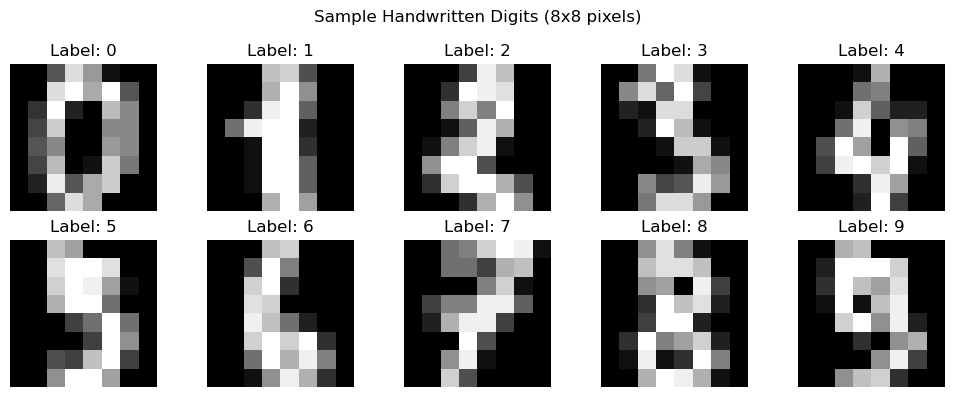


Training: 1437 samples, Testing: 360 samples

Sample GDF sequence (first digit):
  Event 1 (vector): {vectors: [<64-dim vector>], strings: [], emotives: {}}
    First 5 values: [0.0, 0.0, 5.0, 13.0, 9.0]
  Event 2 (label):  {'strings': ['label|0'], 'vectors': [], 'emotives': {}}


In [36]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Load the digits dataset
digits = load_digits()
print(f"Dataset: {digits.data.shape[0]} samples, {digits.data.shape[1]} features, {len(digits.target_names)} classes (0-9)")

# Visualize sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Sample Handwritten Digits (8x8 pixels)")
plt.tight_layout()
plt.show()

# Format into GDF sequences: [vector_event, label_event]
# Each image is flattened to a 1D list of 64 pixel values.
# vectors field expects list[list[float]] — one vector per observation.
digits_dataset = []
for i in range(len(digits.data)):
    flat_vector = digits.data[i].flatten().tolist()  # 1D list of 64 floats
    label = int(digits.target[i])
    sequence = [
        {"vectors": [flat_vector], "strings": [], "emotives": {}},
        {"strings": [f"label|{label}"], "vectors": [], "emotives": {}}
    ]
    digits_dataset.append(sequence)

# Train/test split (80/20)
train_idx, test_idx = train_test_split(
    range(len(digits_dataset)), test_size=0.2, random_state=42, stratify=digits.target
)
digits_train = [digits_dataset[i] for i in train_idx]
digits_test = [digits_dataset[i] for i in test_idx]
print(f"\nTraining: {len(digits_train)} samples, Testing: {len(digits_test)} samples")

# Show sample GDF sequence to verify format
sample_vec = digits_dataset[0][0]['vectors']
print(f"\nSample GDF sequence (first digit):")
print(f"  Event 1 (vector): {{vectors: [<{len(sample_vec[0])}-dim vector>], strings: [], emotives: {{}}}}")
print(f"    First 5 values: {sample_vec[0][:5]}")
print(f"  Event 2 (label):  {digits_dataset[0][1]}")

In [37]:
# Create a fresh session for digits classification
digits_session = create_session("Digits Classification", node_id="digits_classifier", recall_threshold=0.1)
clear_all_memory(digits_session)

# Train
print("\n\U0001f393 Training on handwritten digits...")
train_sequences(digits_session, digits_train)

# Test
print("\n\U0001f9ea Testing on held-out digits...")
digits_preds, digits_actuals = test_classification(digits_session, digits_test)

# Calculate accuracy
digits_top_preds = []
for pred_result in digits_preds:
    preds = pred_result.get('predictions', [])
    if preds and preds[0].get('future'):
        digits_top_preds.append(preds[0]['future'][0][0])
    else:
        digits_top_preds.append('Unknown')

accuracy = accuracy_score(digits_actuals, digits_top_preds)
print(f"\n\U0001f4ca Digits Classification Accuracy: {accuracy:.1%}")

# Show some example predictions
print("\nSample predictions (first 10):")
for i in range(min(10, len(digits_top_preds))):
    status = "\u2705" if digits_top_preds[i] == digits_actuals[i] else "\u274c"
    print(f"  {status} Predicted: {digits_top_preds[i]}, Actual: {digits_actuals[i]}")

✅ Created session: Digits Classification
   Session ID: session-a13577d116f841f6914609a1847055c6-1773859575875
   Node ID: digits_classifier
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
🧹 Cleared all memory

🎓 Training on handwritten digits...
  Trained 200/1437 samples...
  Trained 400/1437 samples...
  Trained 600/1437 samples...
  Trained 800/1437 samples...
  Trained 1000/1437 samples...
  Trained 1200/1437 samples...
  Trained 1400/1437 samples...
✅ Training complete: 1437 patterns learned

🧪 Testing on held-out digits...

📊 Digits Classification Accuracy: 96.7%

Sample predictions (first 10):
  ✅ Predicted: label|5, Actual: label|5
  ✅ Predicted: label|2, Actual: label|2
  ✅ Predicted: label|8, Actual: label|8
  ✅ Predicted: label|1, Actual: label|1
  ✅ Predicted: label|7, Actual: label|7
  ✅ Predicted: label|2, Actual: label|2
  ✅ Predicted: label|6, Actual: label|6
  ✅ Predicted: label|2, Actual: label|2
  ✅ Predicted: label|6, Actual: label|6
  ✅ Predict

## 12. Iris Flower Classification

The **Iris** dataset is one of the most classic ML benchmarks. It contains 150 samples of iris flowers with 4 features (sepal length/width, petal length/width) across 3 species (setosa, versicolor, virginica).

Unlike the digits example where vectors represent pixel data, here the vector represents interpretable physical measurements. The GDF format is identical:
- **Event 1**: Feature vector `{vectors: [[5.1, 3.5, 1.4, 0.2]]}`
- **Event 2**: Label string `{strings: ["label|setosa"]}`

In [38]:
from sklearn.datasets import load_iris

# Load iris dataset
iris = load_iris()
print(f"Dataset: {iris.data.shape[0]} samples, {iris.data.shape[1]} features, {len(iris.target_names)} classes")
print(f"Features: {iris.feature_names}")
print(f"Classes: {list(iris.target_names)}")

# Format into GDF sequences
iris_dataset = []
for i in range(len(iris.data)):
    vector = iris.data[i].tolist()
    label = iris.target_names[iris.target[i]]
    sequence = [
        {"vectors": [vector], "strings": [], "emotives": {}},
        {"strings": [f"label|{label}"], "vectors": [], "emotives": {}}
    ]
    iris_dataset.append(sequence)

# Train/test split (80/20)
iris_train_idx, iris_test_idx = train_test_split(
    range(len(iris_dataset)), test_size=0.2, random_state=42, stratify=iris.target
)
iris_train = [iris_dataset[i] for i in iris_train_idx]
iris_test = [iris_dataset[i] for i in iris_test_idx]

# Create session and train
iris_session = create_session("Iris Classification", node_id="iris_classifier", recall_threshold=0.1)
clear_all_memory(iris_session)

print(f"\n\U0001f393 Training on {len(iris_train)} iris samples...")
train_sequences(iris_session, iris_train, verbose=False)
print("\u2705 Training complete")

# Test
print("\U0001f9ea Testing on held-out iris samples...")
iris_preds, iris_actuals = test_classification(iris_session, iris_test)

# Calculate accuracy
iris_top_preds = []
for pred_result in iris_preds:
    preds = pred_result.get('predictions', [])
    if preds and preds[0].get('future'):
        iris_top_preds.append(preds[0]['future'][0][0])
    else:
        iris_top_preds.append('Unknown')

iris_accuracy = accuracy_score(iris_actuals, iris_top_preds)
print(f"\n\U0001f4ca Iris Classification Accuracy: {iris_accuracy:.1%}")

# Show all predictions
print("\nAll predictions:")
for i in range(len(iris_top_preds)):
    status = "\u2705" if iris_top_preds[i] == iris_actuals[i] else "\u274c"
    print(f"  {status} Predicted: {iris_top_preds[i]}, Actual: {iris_actuals[i]}")

Dataset: 150 samples, 4 features, 3 classes
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa', 'versicolor', 'virginica']
✅ Created session: Iris Classification
   Session ID: session-7ae04dd145804bee9f796d8170a32d21-1773860877049
   Node ID: iris_classifier
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
🧹 Cleared all memory

🎓 Training on 120 iris samples...
✅ Training complete
🧪 Testing on held-out iris samples...

📊 Iris Classification Accuracy: 96.7%

All predictions:
  ✅ Predicted: label|setosa, Actual: label|setosa
  ✅ Predicted: label|virginica, Actual: label|virginica
  ✅ Predicted: label|versicolor, Actual: label|versicolor
  ✅ Predicted: label|versicolor, Actual: label|versicolor
  ✅ Predicted: label|setosa, Actual: label|setosa
  ✅ Predicted: label|versicolor, Actual: label|versicolor
  ✅ Predicted: label|setosa, Actual: label|setosa
  ✅ Predicted: label|setosa, Actual: label|setosa
  ✅ Predic

### Tuning Session Configuration

In the GAIuS framework, you would tune the agent with `agent.change_genes(gene_data={'recall_threshold': 0.3})`. In KATO, the equivalent is updating the session configuration via `POST /sessions/{id}/config`:

```python
# Update recall threshold for a session
update_session_config(session_id, {"recall_threshold": 0.3})

# Get current configuration
response = requests.get(f"{KATO_URL}/sessions/{session_id}/config")
print(response.json())
```

Common tunable parameters:
- **`recall_threshold`**: Controls prediction sensitivity (0.0 = return all matches, 1.0 = perfect matches only)
- **`max_pattern_length`**: Controls auto-learning (0 = manual only, N = auto-learn when STM reaches N events)
- **`use_token_matching`**: Enable token-level matching for pipe-delimited strings
- **`sort_symbols`**: Sort symbols before matching (auto-enabled with token matching)

### GAIuS ia-sdk vs KATO API Reference

If you're migrating from the GAIuS `ia-sdk` to KATO, here are the key differences:

| ia-sdk Feature | KATO Equivalent | Notes |
|---|---|---|
| `AgentClient` class | Direct `requests` HTTP calls | No client library for KATO |
| `agent.connect()` | `POST /sessions` with `node_id` | Session-based, not persistent connection |
| `agent.change_genes()` / `agent.get_gene()` | `POST/GET /sessions/{id}/config` | Session config, not genes |
| `agent.set_ingress_nodes()` / `set_query_nodes()` | Not needed | Single-node sessions |
| `agent.show_status()` | No direct equivalent | Use `GET /sessions/{id}` |
| `agent.observe(data=gdf, nodes=...)` | `POST /sessions/{id}/observe` | No node routing needed |
| `agent.learn(nodes=...)` | `POST /sessions/{id}/learn` | Returns pattern name |
| `agent.get_predictions(nodes=...)` | `GET /sessions/{id}/predictions` | Returns `{"predictions": [...]}` |
| `agent.clear_wm(nodes=...)` | `POST /sessions/{id}/clear-stm` | "Working memory" -> "Short-term memory" |
| `agent.clear_all_memory(nodes=...)` | `POST /sessions/{id}/clear-all` | Clears STM + learned patterns |
| `data_ops.Data` | `sklearn.model_selection.train_test_split()` | data_ops expects file-based GDFs; we use in-memory data |
| `prediction_models.average_emotives()` | Not needed | KATO already returns averaged emotive floats |
| Prediction: `preds[0]['future'][0][0]` | `preds['predictions'][0]['future'][0][0]` | KATO wraps in `{"predictions": [...]}` |

## 13. Customer Churn — Utility Polarity Prediction

This section demonstrates **binary classification using emotive values** instead of string labels. Instead of predicting a label like `"label|churned"`, we encode the outcome as a numeric **polarity** in the emotives field:
- Customer **churned** (left): `emotives: {"utility": -100}`
- Customer **stayed**: `emotives: {"utility": 100}`

### Why Polarity?
Sometimes you need a yes/no answer with an associated magnitude. The sign of the predicted utility value tells you the classification, and the magnitude indicates confidence.

### Pipe Character Formatting
Customer features are formatted as `"Key|Value"` strings (e.g., `"State|CA"`, `"Account Length|120"`). This pipe format allows KATO to match on individual feature values within an event.

### GDF Format
```
Sequence = [
    {strings: ["State|CA", "Account Length|120", ...], vectors: [], emotives: {}},
    {strings: [], vectors: [], emotives: {"utility": -100}}
]
```

In [39]:
import pandas as pd

# Load churn dataset
churn_df = pd.read_csv('data/churn.csv')
print(f"Dataset: {churn_df.shape[0]} rows, {churn_df.shape[1]} columns")
print(f"\nChurn distribution:")
print(churn_df['Churn?'].value_counts())
print(f"\nSample row:")
churn_df.head(2)

Dataset: 3333 rows, 21 columns

Churn distribution:
Churn?
False.    2850
True.      483
Name: count, dtype: int64

Sample row:


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.


In [40]:
# Define feature and target columns
# Excluding 'Phone' (unique IDs don't help pattern matching) and 'Churn?' (that's our target)
feature_columns = list(churn_df.drop(columns=['Phone', 'Churn?']).columns)
print(f"Features ({len(feature_columns)}): {feature_columns[:5]}...")

# Split data (10% train, test on next 50 samples for tutorial speed)
train_size = int(len(churn_df) * 0.1)
churn_train = churn_df[:train_size].to_dict('records')
churn_test = churn_df[train_size:train_size + 50].to_dict('records')
print(f"Training: {len(churn_train)} samples, Testing: {len(churn_test)} samples")

# Create session
churn_session = create_session("Churn Prediction", node_id="churn_predictor", recall_threshold=0.1)
clear_all_memory(churn_session)

# Train: observe pipe-formatted features, then observe polarity emotive, then learn
print("\n\U0001f393 Training on customer churn data...")
for idx, row in enumerate(churn_train):
    http.post(f"{KATO_URL}/sessions/{churn_session}/clear-stm", json={})

    # Event 1: Customer features as pipe-delimited strings
    profile_strings = [f"{key}|{value}" for key, value in row.items() if key in feature_columns]
    http.post(f"{KATO_URL}/sessions/{churn_session}/observe",
                  json={"strings": profile_strings, "vectors": [], "emotives": {}})

    # Event 2: Churn outcome as utility polarity
    utility = -100 if row['Churn?'] == 'True.' else 100
    http.post(f"{KATO_URL}/sessions/{churn_session}/observe",
                  json={"strings": [], "vectors": [], "emotives": {"utility": float(utility)}})

    http.post(f"{KATO_URL}/sessions/{churn_session}/learn", json={})
    if (idx + 1) % 50 == 0:
        print(f"  Trained {idx + 1}/{len(churn_train)} samples...")

print(f"\u2705 Trained on {len(churn_train)} customer profiles")

# Test: observe features, get prediction, check utility sign
print("\n\U0001f9ea Testing churn predictions...")
churn_predictions = []
churn_actuals = []

for row in churn_test:
    http.post(f"{KATO_URL}/sessions/{churn_session}/clear-stm", json={})

    # Observe features only (no utility - that's what we're predicting)
    profile_strings = [f"{key}|{value}" for key, value in row.items() if key in feature_columns]
    http.post(f"{KATO_URL}/sessions/{churn_session}/observe",
                  json={"strings": profile_strings, "vectors": [], "emotives": {}})

    # Get predictions
    response = http.get(f"{KATO_URL}/sessions/{churn_session}/predictions")
    preds = response.json() if response.status_code == 200 else {"predictions": []}
    churn_predictions.append(preds)

    # Store actual
    actual_utility = -100 if row['Churn?'] == 'True.' else 100
    churn_actuals.append(actual_utility)

# Extract top prediction utilities and compute accuracy
churn_pred_utilities = []
for pred_result in churn_predictions:
    preds = pred_result.get('predictions', [])
    if preds and 'emotives' in preds[0] and 'utility' in preds[0]['emotives']:
        churn_pred_utilities.append(preds[0]['emotives']['utility'])
    else:
        churn_pred_utilities.append(0)  # Unknown defaults to 0 (no churn)

# Classification: sign of utility determines churn/not-churn
pred_classes = ['churn' if u < 0 else 'stay' for u in churn_pred_utilities]
actual_classes = ['churn' if u < 0 else 'stay' for u in churn_actuals]

churn_accuracy = accuracy_score(actual_classes, pred_classes)
print(f"\n\U0001f4ca Churn Prediction Accuracy: {churn_accuracy:.1%}")

# Show sample predictions
print("\nSample predictions (first 10):")
for i in range(min(10, len(pred_classes))):
    status = "\u2705" if pred_classes[i] == actual_classes[i] else "\u274c"
    print(f"  {status} Predicted utility: {churn_pred_utilities[i]:>7.1f} ({pred_classes[i]}), Actual: {churn_actuals[i]:>4d} ({actual_classes[i]})")

Features (19): ['State', 'Account Length', 'Area Code', "Int'l Plan", 'VMail Plan']...
Training: 333 samples, Testing: 50 samples
✅ Created session: Churn Prediction
   Session ID: session-87de082719d1453e987bd3c9a1b2482b-1773860912791
   Node ID: churn_predictor
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
🧹 Cleared all memory

🎓 Training on customer churn data...
  Trained 50/333 samples...
  Trained 100/333 samples...
  Trained 150/333 samples...
  Trained 200/333 samples...
  Trained 250/333 samples...
  Trained 300/333 samples...
✅ Trained on 333 customer profiles

🧪 Testing churn predictions...

📊 Churn Prediction Accuracy: 80.0%

Sample predictions (first 10):
  ✅ Predicted utility:   100.0 (stay), Actual:  100 (stay)
  ✅ Predicted utility:   100.0 (stay), Actual:  100 (stay)
  ✅ Predicted utility:   100.0 (stay), Actual:  100 (stay)
  ✅ Predicted utility:   100.0 (stay), Actual:  100 (stay)
  ✅ Predicted utility:   100.0 (stay), Actual:  100 (stay)
  ✅ Pr

## 14. California Housing — Utility Value Prediction (Regression)

This section demonstrates **numeric regression** using emotive values. Unlike the churn example where we only care about the sign (positive/negative), here we predict actual numeric values — house prices.

We use `sklearn.datasets.fetch_california_housing()` (the modern replacement for the deprecated `load_boston()`). Features are formatted as pipe-delimited strings, and the target price is stored as `emotives: {"utility": price}`.

### Key Difference from Classification
- **Classification** (Sections 11-13): Extract predicted string label or polarity sign
- **Regression** (this section): Extract predicted emotive value as a continuous number

### GDF Format
```
Sequence = [
    {strings: ["MedInc|8.33", "HouseAge|41", ...], vectors: [], emotives: {}},
    {strings: [], vectors: [], emotives: {"utility": 4.526}}
]
```

In [41]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load California Housing dataset (subsampled for tutorial speed)
housing = fetch_california_housing()
print(f"Full dataset: {housing.data.shape[0]} samples, {housing.data.shape[1]} features")
print(f"Features: {housing.feature_names}")
print(f"Target: Median house value (in $100k)")

# Subsample to ~500 for tutorial speed
np.random.seed(42)
sample_idx = np.random.choice(len(housing.data), size=500, replace=False)
housing_data = housing.data[sample_idx]
housing_target = housing.target[sample_idx]

# Format into GDF sequences with pipe-formatted strings and utility emotives
housing_dataset = []
for i in range(len(housing_data)):
    # Event 1: Features as pipe-delimited strings
    feature_strings = [f"{name}|{round(val, 2)}" for name, val in zip(housing.feature_names, housing_data[i])]
    # Event 2: Price as utility emotive
    price = round(float(housing_target[i]), 2)
    sequence = [
        {"strings": feature_strings, "vectors": [], "emotives": {}},
        {"strings": [], "vectors": [], "emotives": {"utility": price}}
    ]
    housing_dataset.append(sequence)

# Train/test split (80/20)
h_train_idx, h_test_idx = train_test_split(range(len(housing_dataset)), test_size=0.2, random_state=42)
h_train = [housing_dataset[i] for i in h_train_idx]
h_test = [housing_dataset[i] for i in h_test_idx]

print(f"\nSubsampled: {len(housing_dataset)} samples")
print(f"Training: {len(h_train)}, Testing: {len(h_test)}")
print(f"\nSample GDF sequence:")
print(f"  Event 1: {{strings: {housing_dataset[0][0]['strings'][:3]}..., emotives: {{}}}}")
print(f"  Event 2: {{strings: [], emotives: {housing_dataset[0][1]['emotives']}}}")

# Create session and train
housing_session = create_session("Housing Regression", node_id="housing_predictor", recall_threshold=0.1)
clear_all_memory(housing_session)

print(f"\n\U0001f393 Training on {len(h_train)} housing samples...")
train_sequences(housing_session, h_train)

# Test: observe features, predict utility value
print("\n\U0001f9ea Testing housing price predictions...")
h_pred_values = []
h_actual_values = []

for seq in h_test:
    http.post(f"{KATO_URL}/sessions/{housing_session}/clear-stm", json={})
    http.post(f"{KATO_URL}/sessions/{housing_session}/observe", json=seq[0])

    response = http.get(f"{KATO_URL}/sessions/{housing_session}/predictions")
    preds = response.json() if response.status_code == 200 else {"predictions": []}

    pred_list = preds.get('predictions', [])
    if pred_list and 'emotives' in pred_list[0] and 'utility' in pred_list[0]['emotives']:
        h_pred_values.append(pred_list[0]['emotives']['utility'])
    else:
        h_pred_values.append(np.nan)

    h_actual_values.append(seq[-1]['emotives']['utility'])

# Calculate metrics (excluding NaN predictions)
valid = [(p, a) for p, a in zip(h_pred_values, h_actual_values) if not np.isnan(p)]
if valid:
    valid_preds, valid_actuals = zip(*valid)
    mae = mean_absolute_error(valid_actuals, valid_preds)
    rmse = np.sqrt(mean_squared_error(valid_actuals, valid_preds))
    response_rate = len(valid) / len(h_test) * 100

    print(f"\n\U0001f4ca Housing Regression Metrics:")
    print(f"   Response Rate: {response_rate:.0f}% ({len(valid)}/{len(h_test)} predictions)")
    print(f"   MAE:  {mae:.2f} ($100k)")
    print(f"   RMSE: {rmse:.2f} ($100k)")

    # Show sample predictions
    print(f"\nSample predictions (first 10 valid):")
    count = 0
    for p, a in zip(h_pred_values, h_actual_values):
        if not np.isnan(p) and count < 10:
            print(f"  Predicted: ${p*100:.0f}k, Actual: ${a*100:.0f}k, Error: ${abs(p-a)*100:.0f}k")
            count += 1
else:
    print("\u274c No valid predictions (try adjusting recall_threshold)")

Full dataset: 20640 samples, 8 features
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: Median house value (in $100k)

Subsampled: 500 samples
Training: 400, Testing: 100

Sample GDF sequence:
  Event 1: {strings: ['MedInc|1.68', 'HouseAge|25.0', 'AveRooms|4.19']..., emotives: {}}
  Event 2: {strings: [], emotives: {'utility': 0.48}}
✅ Created session: Housing Regression
   Session ID: session-1adcbd114b1d43fe80fd93ba1c8a47e3-1773861598421
   Node ID: housing_predictor
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.1
🧹 Cleared all memory

🎓 Training on 400 housing samples...
  Trained 200/400 samples...
  Trained 400/400 samples...
✅ Training complete: 400 patterns learned

🧪 Testing housing price predictions...

📊 Housing Regression Metrics:
   Response Rate: 100% (100/100 predictions)
   MAE:  1.32 ($100k)
   RMSE: 1.72 ($100k)

Sample predictions (first 10 valid):
  Predicted: $108k, Actual: $227

## 15. Auto MPG Recommendation Engine with Emotives

This section demonstrates the most advanced emotive usage: a **recommendation engine** with conflicting objectives and mood-based sorting.

### Key Concepts
1. **Dual Emotives**: Each car has both `horsepower` and `mpg` emotive values (inversely correlated)
2. **Single-Event GDF**: Unlike previous sections with two-event sequences, each car is a **single event** combining features and emotives
3. **Recommendation via `missing` field**: After observing partial features (e.g., "4 cylinders, 1982"), predictions contain `missing` fields showing what else the agent expected — these are the recommendations
4. **Mood-Based Sorting**: Different mood weights change how predictions are ranked, enabling personalized recommendations

### The Scenario
A user asks: *"Recommend a 4-cylinder 1982 car."* Depending on their mood (fuel-efficient vs performance), they get different recommendations.

### GDF Format (Single Event)
```
Sequence = [
    {strings: ["cylinders|4", "weight|2790", "car name|ford mustang gl"],
     vectors: [], emotives: {"horsepower": 0.045, "mpg": 0.062}}
]
```

Original dataset: 398 rows
After cleaning: 392 rows


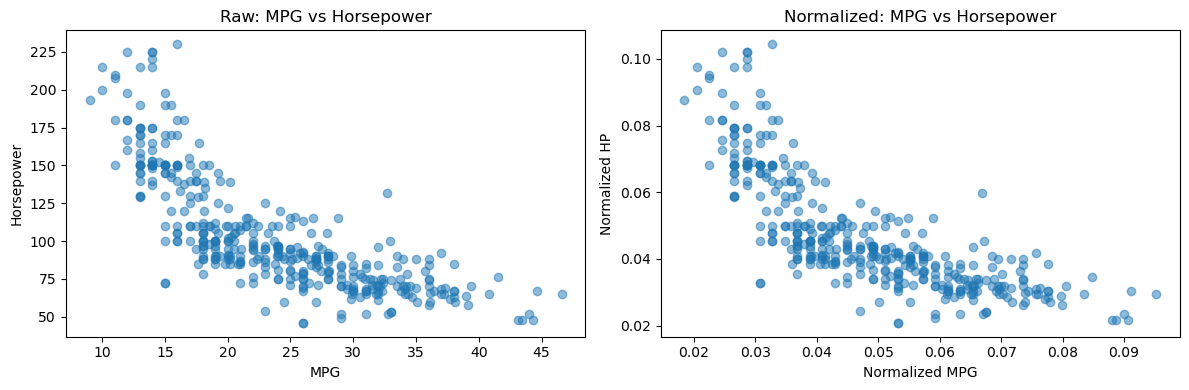


Feature columns (strings): ['cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin', 'car name']
Emotive columns: ['mpg', 'horsepower']

Formatted 392 single-event GDFs
Sample GDF:
  strings: ['cylinders|8', 'displacement|307.0', 'weight|3504']...
  emotives: {'horsepower': 0.058984224625244115, 'mpg': 0.03679560492881037}


In [42]:
from sklearn.preprocessing import normalize

# Load and clean Auto MPG dataset
auto_mpg_df = pd.read_csv('data/auto-mpg.csv')
print(f"Original dataset: {len(auto_mpg_df)} rows")

# Remove rows with '?' in horsepower and convert to float
auto_mpg_df = auto_mpg_df[auto_mpg_df.horsepower != '?'].copy()
auto_mpg_df['horsepower'] = auto_mpg_df['horsepower'].astype(float)
print(f"After cleaning: {len(auto_mpg_df)} rows")

# Normalize HP and MPG to comparable ranges for fair emotive comparison
norm_mpg = normalize([auto_mpg_df['mpg'].values], norm='l2')[0]
norm_hp = normalize([auto_mpg_df['horsepower'].values], norm='l2')[0]

# Plot the inverse relationship
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(auto_mpg_df['mpg'], auto_mpg_df['horsepower'], alpha=0.5)
ax1.set_xlabel('MPG'); ax1.set_ylabel('Horsepower'); ax1.set_title('Raw: MPG vs Horsepower')
ax2.scatter(norm_mpg, norm_hp, alpha=0.5)
ax2.set_xlabel('Normalized MPG'); ax2.set_ylabel('Normalized HP'); ax2.set_title('Normalized: MPG vs Horsepower')
plt.tight_layout()
plt.show()

# Update dataframe with normalized values
auto_mpg_df['mpg'] = norm_mpg
auto_mpg_df['horsepower'] = norm_hp

# Define columns: features (strings) vs emotives
emotive_columns = ['mpg', 'horsepower']
feature_columns_mpg = [c for c in auto_mpg_df.columns if c not in emotive_columns]
print(f"\nFeature columns (strings): {feature_columns_mpg}")
print(f"Emotive columns: {emotive_columns}")

# Format as single-event GDFs (features as strings + dual emotives)
auto_mpg_gdfs = []
rows = auto_mpg_df.to_dict('records')
for row in rows:
    strings = [f"{k}|{v}" for k, v in row.items() if k in feature_columns_mpg]
    emotives = {"horsepower": float(row['horsepower']), "mpg": float(row['mpg'])}
    auto_mpg_gdfs.append([{"strings": strings, "vectors": [], "emotives": emotives}])

print(f"\nFormatted {len(auto_mpg_gdfs)} single-event GDFs")
print(f"Sample GDF:")
print(f"  strings: {auto_mpg_gdfs[0][0]['strings'][:3]}...")
print(f"  emotives: {auto_mpg_gdfs[0][0]['emotives']}")

In [43]:
# Create session and train
mpg_session = create_session("Auto MPG Recommender", node_id="mpg_recommender", recall_threshold=0.3)
clear_all_memory(mpg_session)

print("\U0001f393 Training on auto MPG data...")
train_sequences(mpg_session, auto_mpg_gdfs)

# Helper: recommend cars based on mood
def recommend_with_mood(predictions, mood):
    """Sort predictions by mood-weighted emotives x potential.

    mood: dict with emotive weights, e.g., {"horsepower": 1.0, "mpg": 1.0}
    Returns sorted predictions (highest recommendation score first).
    """
    def score(pred):
        emotives = pred.get('emotives', {})
        weighted_sum = sum(emotives.get(k, 0) * mood.get(k, 1.0) for k in mood)
        avg = weighted_sum / len(mood) if mood else 0
        return avg * pred.get('potential', 0)

    return sorted(predictions, key=score, reverse=True)

def get_car_name(pred):
    """Extract car name from a prediction's missing field."""
    for sym in pred.get('missing', []):
        for item in sym:
            if 'car name|' in str(item):
                return item.split('|', 1)[1]
        return "Unknown"

# Observe: "I want a 4-cylinder car from 1982"
clear_stm(mpg_session)
observe(mpg_session, strings=["cylinders|4", "model year|82"])

# Get predictions
response = http.get(f"{KATO_URL}/sessions/{mpg_session}/predictions")
preds_data = response.json()
preds = preds_data.get('predictions', [])
print(f"\n\U0001f52e Found {len(preds)} matching predictions for '4 cylinders, model year 82'\n")

# === Mood 1: Balanced ===
print("=" * 60)
print("\U0001f3ad MOOD 1: Balanced (horsepower=1.0, mpg=1.0)")
print("=" * 60)
balanced = recommend_with_mood(preds, {"horsepower": 1.0, "mpg": 1.0})
for i, pred in enumerate(balanced[:3]):
    name = get_car_name(pred)
    emots = pred.get('emotives', {})
    print(f"  #{i+1}: {name}")
    print(f"       HP: {emots.get('horsepower', 0):.4f}, MPG: {emots.get('mpg', 0):.4f}, Potential: {pred.get('potential', 0):.4f}")

# === Mood 2: Fuel-Efficient ===
print(f"\n{'=' * 60}")
print("\u26fd MOOD 2: Fuel-Efficient (horsepower=0.5, mpg=1.5)")
print("=" * 60)
fuel_eff = recommend_with_mood(preds, {"horsepower": 0.5, "mpg": 1.5})
for i, pred in enumerate(fuel_eff[:3]):
    name = get_car_name(pred)
    emots = pred.get('emotives', {})
    print(f"  #{i+1}: {name}")
    print(f"       HP: {emots.get('horsepower', 0):.4f}, MPG: {emots.get('mpg', 0):.4f}, Potential: {pred.get('potential', 0):.4f}")

# === Mood 3: Performance ===
print(f"\n{'=' * 60}")
print("\U0001f3ce\ufe0f  MOOD 3: Performance (horsepower=1.5, mpg=0.5)")
print("=" * 60)
performance = recommend_with_mood(preds, {"horsepower": 1.5, "mpg": 0.5})
for i, pred in enumerate(performance[:3]):
    name = get_car_name(pred)
    emots = pred.get('emotives', {})
    print(f"  #{i+1}: {name}")
    print(f"       HP: {emots.get('horsepower', 0):.4f}, MPG: {emots.get('mpg', 0):.4f}, Potential: {pred.get('potential', 0):.4f}")

# Summary
print(f"\n\U0001f4ca Mood Comparison - Top Recommendations:")
print(f"  Balanced:       {get_car_name(balanced[0]) if balanced else 'N/A'}")
print(f"  Fuel-Efficient: {get_car_name(fuel_eff[0]) if fuel_eff else 'N/A'}")
print(f"  Performance:    {get_car_name(performance[0]) if performance else 'N/A'}")

✅ Created session: Auto MPG Recommender
   Session ID: session-a7fc49df8a0344a389080993991abbdc-1773861881731
   Node ID: mpg_recommender
   Max pattern length: 0 (manual learning)
   Recall threshold: 0.3
🧹 Cleared all memory
🎓 Training on auto MPG data...
  Trained 200/392 samples...
✅ Training complete: 392 patterns learned
🧹 Cleared short-term memory
📥 Observed: ['cylinders|4', 'model year|82']

🔮 Found 27 matching predictions for '4 cylinders, model year 82'

🎭 MOOD 1: Balanced (horsepower=1.0, mpg=1.0)
  #1: vw pickup
       HP: 0.0236, MPG: 0.0899, Potential: 2.0693
  #2: nissan stanza xe
       HP: 0.0399, MPG: 0.0736, Potential: 2.0686
  #3: dodge charger 2.2
       HP: 0.0381, MPG: 0.0736, Potential: 2.0579

⛽ MOOD 2: Fuel-Efficient (horsepower=0.5, mpg=1.5)
  #1: vw pickup
       HP: 0.0236, MPG: 0.0899, Potential: 2.0693
  #2: datsun 310 gx
       HP: 0.0304, MPG: 0.0777, Potential: 2.0688
  #3: honda civic
       HP: 0.0304, MPG: 0.0777, Potential: 2.0687

🏎️  MOOD 3: Perf

## Conclusion

Congratulations! You've completed the comprehensive KATO tutorial. You've explored:

**Core Concepts (Sections 1-4)**
- Sessions, nodes, observations, and predictions
- API fundamentals: creating sessions, observing data, learning patterns
- Deep dive into prediction fields and temporal segmentation

**Advanced Features (Sections 5-10)**
- Prediction metrics: confidence, potential, and recall thresholds
- Emotives: adding emotional context to observations
- Vector data and Word2Vec integration
- Learning modes: manual vs automatic
- Abstraction chains: hierarchical pattern learning

**Real-World Datasets (Sections 11-15)**
- Handwritten Digits: Vector classification with 64-dimensional pixel data
- Iris Flowers: Classic ML benchmark with interpretable features
- Customer Churn: Binary classification via utility polarity emotives
- California Housing: Numeric regression via utility value emotives
- Auto MPG: Recommendation engine with conflicting dual emotives and mood-based sorting

### Choosing the Right Approach

| Task Type | GDF Pattern | Prediction Extraction |
|---|---|---|
| **String Classification** (Sec 11-12) | `[{vectors: [...]}, {strings: ["label\|X"]}]` | `preds[0]['future'][0][0]` |
| **Polarity Classification** (Sec 13) | `[{strings: ["feat\|val", ...]}, {emotives: {"utility": +/-100}}]` | Sign of `preds[0]['emotives']['utility']` |
| **Value Regression** (Sec 14) | `[{strings: ["feat\|val", ...]}, {emotives: {"utility": price}}]` | `preds[0]['emotives']['utility']` as number |
| **Recommendations** (Sec 15) | `[{strings: ["feat\|val", ...], emotives: {"a": X, "b": Y}}]` | `preds[0]['missing']` + mood-weighted sorting |

### KATO API Quick Reference
- **Health**: `GET /health`
- **Sessions**: `POST /sessions`, `GET /sessions/{id}`, `DELETE /sessions/{id}`
- **Observe**: `POST /sessions/{id}/observe`, `POST /sessions/{id}/observe-sequence`
- **Learn**: `POST /sessions/{id}/learn`
- **Predict**: `GET /sessions/{id}/predictions`
- **Config**: `GET/POST /sessions/{id}/config`
- **Memory**: `POST /sessions/{id}/clear-stm`, `POST /sessions/{id}/clear-all`

KATO's deterministic, transparent approach to pattern learning enables explainable AI systems that humans can understand, trust, and integrate into real-world workflows.